# **Fine-Tuning Llama 3.1 8B for Clinical Note Generation**

## Introduction

### The Problem: Documentation Burden in Healthcare

After every patient visit, doctors are required to produce a detailed clinical note documenting the encounter. These notes typically include structured sections such as the Chief Complaint, History of Present Illness, Physical Examination findings, Assessment, and Plan. This documentation is essential for continuity of care, medical billing, legal compliance, and communication between healthcare providers.

However, writing these notes is one of the most time-consuming and tedious parts of a physician's day. Studies have shown that doctors spend nearly **two hours on documentation for every one hour of direct patient care**. Many physicians end up completing their notes after clinic hours — a practice so widespread it has earned the name **"pajama time"** in the medical community. This administrative burden is a leading driver of **physician burnout**, contributes to reduced face-to-face time with patients, and ultimately impacts the quality of care delivered.

### My Approach

In this project, I fine-tune **Meta-Llama-3.1-8B-Instruct** — a state-of-the-art open-source LLM — on the **ACI-Bench** dataset, which contains real doctor-patient conversation transcripts paired with gold-standard clinical notes. I use **QLoRA** (Quantized Low-Rank Adaptation) to make fine-tuning feasible on a single GPU by training only ~0.5-1% of the model's parameters while keeping the rest frozen in 4-bit precision.

Our goal is to take a raw conversation transcript like this:

```
[doctor] hi, how are you feeling today?
[patient] i've been having this persistent cough for about two weeks...
[doctor] any fever, shortness of breath, or chest pain?
[patient] no fever, but i do feel short of breath when i climb stairs...
```

And automatically generate a structured clinical note like this:

```
CHIEF COMPLAINT
Persistent cough for two weeks.

HISTORY OF PRESENT ILLNESS
Patient is a 45-year-old female presenting with a two-week history
of persistent cough with associated dyspnea on exertion...

PHYSICAL EXAMINATION
Lungs clear to auscultation bilaterally. No wheezing...

ASSESSMENT AND PLAN
Post-viral cough. Prescribe cough suppressant...
```

### Why This Task Is Challenging

* **Long-form generation** — Clinical notes are 300-600 words, requiring the model to maintain coherence and accuracy over many paragraphs
* **Medical accuracy** — The model must extract and reproduce specific clinical details (medication names, dosages, test results, exam findings) without fabricating information
* **Structural compliance** — Notes must follow a standardized format with specific section headers that vary by visit type
* **Information synthesis** — A 10-minute conversation contains many exchanges, asides, and repetitions. The model must distill this into a concise, organized narrative
* **Data scarcity** — Annotated medical conversation-note pairs are rare due to privacy regulations (HIPAA), making it difficult to obtain large training datasets. Our training set contains only 67 examples.

### What is Delivered

This project covers the full fine-tuning pipeline:

* **Dataset preparation** — Loading, cleaning, deduplication, and formatting of ACI-Bench data into train/validation/test splits
* **Model selection and setup** — Llama 3.1 8B with QLoRA adapters via Unsloth
* **Hyperparameter optimization** — Three configurations tested with different learning rates, LoRA ranks, epoch counts, and schedulers
* **Comprehensive evaluation** — Six metrics (ROUGE-1/2/L, BERTScore, BLEURT, Medical Entity F1) plus custom section-level and medical quality metrics
* **Error analysis** — Identification of failure patterns (hallucination, incompleteness, missing sections) with root cause analysis
* **Inference pipeline** — A functional interface for generating clinical notes from new transcripts

### Environment Setup — Install Required Libraries

Installs the core dependencies needed for this project:
- **Unsloth** — Provides optimized LoRA/QLoRA fine-tuning with ~2x speedup and 60% less memory compared to standard HuggingFace training. This is why I chose Unsloth over vanilla `peft` + `transformers`.
- **rouge-score** — Computes ROUGE-1, ROUGE-2, and ROUGE-L metrics (measures n-gram overlap between generated and reference text)
- **bert-score** — Computes BERTScore (measures semantic similarity using contextual embeddings from a pre-trained BERT model)

> After running this cell, **restart the runtime** before proceeding.

In [ ]:
# CELL 1: Installation (run this, then restart runtime)

# %%capture
!pip install unsloth
!pip install rouge-score bert-score gradio

In [ ]:
!pip install --upgrade evaluate
!pip install git+https://github.com/google-research/bleurt.git

### Install BLEURT Evaluation Metric

BLEURT (Bilingual Evaluation Understudy with Representations from Transformers) is a **learned evaluation metric** trained on human ratings of text quality. Unlike ROUGE (which only measures surface-level word overlap), BLEURT captures deeper semantic quality and correlates better with human judgment. I use the `BLEURT-20` checkpoint, which is the latest and most accurate version.

In [61]:
from evaluate import load
bleurt = load('bleurt', config_name='BLEURT-20')

Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.14s/it]

### Import All Required Libraries

Key imports and why each is needed:
- **`unsloth` / `FastLanguageModel`** — Must be imported **first** (before other torch-based libraries) to properly patch the model for optimized training
- **`SFTTrainer`** (from `trl`) — Supervised Fine-Tuning trainer specifically designed for instruction-tuning LLMs
- **`TrainingArguments`** — Configures all training hyperparameters (learning rate, batch size, epochs, etc.)
- **`Dataset`** (from HuggingFace `datasets`) — Standard format expected by `SFTTrainer`
- **`rouge_scorer` / `bert_score_fn`** — Evaluation metrics for measuring generation quality
- **`train_test_split`** — For splitting data if the dataset doesn't come pre-split

Also verifies that CUDA (GPU) is available — essential for training an 8B parameter model.

In [76]:
# CELL 2: Imports (unsloth MUST be first)
import unsloth
from unsloth import FastLanguageModel
import re
import os
import json
import torch
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.model_selection import train_test_split
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import warnings
warnings.filterwarnings("ignore")

print("All imports successful!")
print(f"CUDA available: {torch.cuda.is_available()}")

All imports successful!
CUDA available: True


### Download the ACI-Bench Dataset

Clones the **ACI-Bench** (Ambient Clinical Intelligence Benchmark) repository from GitHub. This dataset was chosen because:
- It contains real doctor-patient conversation transcripts paired with structured clinical notes
- It is domain-specific to our task (medical conversation → clinical note generation)
- It includes multiple test sets from clinical NLP shared tasks, providing robust evaluation data
- The source (`src`) fields contain conversation transcripts and the target (`tgt`) fields contain the corresponding clinical notes

In [ ]:
!git clone https://github.com/wyim/aci-bench.git

### Define Data Loading Utilities

Two helper functions for loading the ACI-Bench dataset:

**`load_json_file(filepath)`:**
- Reads a single JSON file and extracts `src` (transcript), `tgt` (clinical note), and `file` (unique ID)
- Only keeps records where both `src` and `tgt` are non-empty (data cleaning)

**`load_split(base_path, split_name)`:**
- Loads all relevant JSON files for a given split (train/valid/test)
- Searches both `challenge_data_json/` and `src_experiment_data_json/` directories
- Skips section-specific files (e.g., `_subjective`, `_objective_exam`) — I use **full notes** only, since our task is to generate the complete clinical note
- **Deduplicates** by `file_id` to prevent data leakage from overlapping sources

In [ ]:
def load_json_file(filepath):
    """Load a single ACI-Bench JSON file and extract src/tgt pairs."""
    records = []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # The JSON structure has a "data" key containing list of records
        for item in data.get("data", []):
            src = item.get("src", "")
            tgt = item.get("tgt", "")
            file_id = item.get("file", "")
            if src and tgt:
                records.append({
                    'transcript': src,
                    'note': tgt,
                    'file_id': file_id
                })
    except Exception as e:
        print(f"  Error loading {filepath}: {e}")
    return records


def load_split(base_path, split_name):
    """
    Load all JSON files for a given split.
    Looks in both challenge_data_json/ and src_experiment_data_json/ directories.
    """
    records = []

    # Primary location: challenge_data_json
    challenge_json_dir = os.path.join(base_path, "data", "challenge_data_json")
    # Secondary location: src_experiment_data_json
    src_json_dir = os.path.join(base_path, "data", "src_experiment_data_json")

    # Map split names to file patterns
    split_patterns = {
        'train': ['train*.json'],
        'valid': ['valid*.json'],
        'test1': ['clinicalnlp_taskB_test1*.json'],
        'test2': ['clinicalnlp_taskC_test2*.json'],
        'test3': ['clef_taskC_test3*.json'],
        # src_experiment_data files
        'test1_src': ['test1_*.json'],
        'test2_src': ['test2_*.json'],
        'test3_src': ['test3_*.json'],
    }

    patterns = split_patterns.get(split_name, [])

    # Search in challenge_data_json
    for pattern in patterns:
        for filepath in glob.glob(os.path.join(challenge_json_dir, pattern)):
            filename = os.path.basename(filepath)
            # Skip section-specific files for now, use full notes
            if '_full.' in filename or not any(x in filename for x in
                ['_assessment_and_plan.', '_objective_exam.', '_objective_results.', '_subjective.']):
                print(f"  Loading: {filepath}")
                new_records = load_json_file(filepath)
                records.extend(new_records)

    # Search in src_experiment_data_json
    for pattern in split_patterns.get(f'{split_name}_src', []):
        for filepath in glob.glob(os.path.join(src_json_dir, pattern)):
            print(f"  Loading: {filepath}")
            new_records = load_json_file(filepath)
            records.extend(new_records)

    # Deduplicate by file_id
    seen = set()
    unique_records = []
    for r in records:
        if r['file_id'] not in seen:
            seen.add(r['file_id'])
            unique_records.append(r)

    return unique_records


### Verify Dataset Directory Structure

Quick sanity check to confirm:
- The `aci-bench` repo was cloned successfully
- The expected subdirectories (`challenge_data_json/`, `src_experiment_data_json/`) exist

In [99]:
import os
print("cwd:", os.getcwd())
print("aci-bench exists?", os.path.exists("aci-bench"))
!ls -la
!ls -la aci-bench/data || true

cwd: /content
aci-bench exists? True
total 52
drwxr-xr-x  1 root root 4096 Feb  9 03:21 .
drwxr-xr-x  1 root root 4096 Feb  9 01:46 ..
drwxr-xr-x 11 root root 4096 Feb  9 02:53 aci-bench
drwxr-xr-x  4 root root 4096 Dec  9 14:41 .config
drwxr-xr-x  4 root root 4096 Feb  9 01:53 huggingface_tokenizers_cache
drwxr-xr-x  2 root root 4096 Feb  9 02:53 .ipynb_checkpoints
drwxr-xr-x  4 root root 4096 Feb  9 03:11 outputs_config1
drwxr-xr-x  4 root root 4096 Feb  9 03:54 outputs_config2
drwxr-xr-x  4 root root 4096 Feb  9 02:03 outputs_config3
drwxr-xr-x  3 root root 4096 Feb  9 02:53 package
drwxr-xr-x  2 root root 4096 Feb  9 02:51 __pycache__
drwxr-xr-x  1 root root 4096 Dec  9 14:42 sample_data
drwxr-xr-x  4 root root 4096 Feb  9 01:52 unsloth_compiled_cache
total 24
drwxr-xr-x  6 root root 4096 Feb  9 01:52 .
drwxr-xr-x 11 root root 4096 Feb  9 02:53 ..
drwxr-xr-x  2 root root 4096 Feb  9 01:52 challenge_data
drwxr-xr-x  2 root root 4096 Feb  9 01:52 challenge_data_json
drwxr-xr-x  2 roo

### Load Train, Validation, and Test Splits

Loads data from the ACI-Bench dataset into three splits:
- **Train** — 67 samples used for fine-tuning
- **Validation** — 20 samples used for monitoring overfitting during training
- **Test** — 70 samples used for final evaluation (from `test1` — clinicalnlp TaskB)

The test set intentionally comes from a different source than training data, which helps evaluate generalization. A fallback mechanism is included: if any split is empty, all available data is loaded and split manually (70/15/15 ratio).

In [100]:
import glob

BASE_PATH = "aci-bench"

print("=" * 60)
print("Loading ACI-Bench Dataset")
print("=" * 60)

# First, let's see what files are available
print("\nAvailable JSON files in challenge_data_json/:")
challenge_dir = os.path.join(BASE_PATH, "data", "challenge_data_json")
if os.path.exists(challenge_dir):
    for f in sorted(os.listdir(challenge_dir)):
        if f.endswith('.json'):
            print(f"  {f}")
else:
    print("  Directory not found!")

print("\nAvailable JSON files in src_experiment_data_json/:")
src_dir = os.path.join(BASE_PATH, "data", "src_experiment_data_json")
if os.path.exists(src_dir):
    for f in sorted(os.listdir(src_dir)):
        if f.endswith('.json'):
            print(f"  {f}")
else:
    print("  Directory not found!")

# Load each split
print("\n--- Loading Train ---")
train_data = load_split(BASE_PATH, 'train')

print("\n--- Loading Validation ---")
valid_data = load_split(BASE_PATH, 'valid')

print("\n--- Loading Test (using test1 - clinicalnlp TaskB) ---")
test_data = load_split(BASE_PATH, 'test1')

# If test1 from challenge_data is empty, try src_experiment_data
if not test_data:
    print("  Trying src_experiment_data for test...")
    for filepath in glob.glob(os.path.join(src_dir, "test1_*.json")):
        print(f"  Loading: {filepath}")
        test_data.extend(load_json_file(filepath))

# Fallback: if any split is empty, load ALL available data and split manually
if not train_data:
    print("\n⚠️  Train data not found in expected location. Loading all available JSON files...")
    all_records = []
    for search_dir in [challenge_dir, src_dir]:
        if os.path.exists(search_dir):
            for filepath in glob.glob(os.path.join(search_dir, "*.json")):
                filename = os.path.basename(filepath)
                # Use full note files, skip section-specific ones
                if any(x in filename for x in ['_assessment_and_plan.', '_objective_exam.',
                       '_objective_results.', '_subjective.']):
                    continue
                new_records = load_json_file(filepath)
                if new_records:
                    print(f"  Loaded {len(new_records)} records from {filename}")
                    all_records.extend(new_records)

    # Deduplicate
    seen = set()
    unique_all = []
    for r in all_records:
        key = r['file_id'] if r['file_id'] else r['transcript'][:100]
        if key not in seen:
            seen.add(key)
            unique_all.append(r)

    print(f"\n  Total unique records: {len(unique_all)}")

    # Split: 70% train, 15% valid, 15% test
    from sklearn.model_selection import train_test_split
    train_data, temp_data = train_test_split(unique_all, test_size=0.3, random_state=42)
    valid_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"\n{'=' * 60}")
print(f"Dataset Sizes:")
print(f"  Train: {len(train_data)}")
print(f"  Valid: {len(valid_data)}")
print(f"  Test:  {len(test_data)}")
print(f"{'=' * 60}")

Loading ACI-Bench Dataset

Available JSON files in challenge_data_json/:
  clef_taskC_test3.json
  clef_taskC_test3_assessment_and_plan.json
  clef_taskC_test3_full.json
  clef_taskC_test3_objective_exam.json
  clef_taskC_test3_objective_results.json
  clef_taskC_test3_subjective.json
  clinicalnlp_taskB_test1.json
  clinicalnlp_taskB_test1_assessment_and_plan.json
  clinicalnlp_taskB_test1_full.json
  clinicalnlp_taskB_test1_objective_exam.json
  clinicalnlp_taskB_test1_objective_results.json
  clinicalnlp_taskB_test1_subjective.json
  clinicalnlp_taskC_test2.json
  clinicalnlp_taskC_test2_assessment_and_plan.json
  clinicalnlp_taskC_test2_full.json
  clinicalnlp_taskC_test2_objective_exam.json
  clinicalnlp_taskC_test2_objective_results.json
  clinicalnlp_taskC_test2_subjective.json
  train.json
  train_assessment_and_plan.json
  train_full.json
  train_objective_exam.json
  train_objective_results.json
  train_subjective.json
  valid.json
  valid_assessment_and_plan.json
  valid_ful

### Inspect a Sample Transcript and Clinical Note

Displays the first 500 characters of a sample transcript and its corresponding clinical note. This verifies:
- Data was loaded correctly
- The transcript format (e.g., `[doctor]` / `[patient]` speaker tags)
- The clinical note structure (e.g., `CHIEF COMPLAINT`, `HISTORY OF PRESENT ILLNESS`, etc.)

In [101]:
if train_data:
    sample = train_data[0]
    print(f"\n{'=' * 60}")
    print("SAMPLE TRANSCRIPT (first 500 chars):")
    print(f"{'=' * 60}")
    print(sample['transcript'][:500])
    print(f"\n{'=' * 60}")
    print("SAMPLE CLINICAL NOTE (first 500 chars):")
    print(f"{'=' * 60}")
    print(sample['note'][:500])


SAMPLE TRANSCRIPT (first 500 chars):
[doctor] hi , martha . how are you ?
[patient] i'm doing okay . how are you ?
[doctor] i'm doing okay . so , i know the nurse told you about dax . i'd like to tell dax a little bit about you , okay ?
[patient] okay .
[doctor] martha is a 50-year-old female with a past medical history significant for congestive heart failure , depression and hypertension who presents for her annual exam . so , martha , it's been a year since i've seen you . how are you doing ?
[patient] i'm doing well . i've been

SAMPLE CLINICAL NOTE (first 500 chars):
CHIEF COMPLAINT

Annual exam.

HISTORY OF PRESENT ILLNESS

Martha Collins is a 50-year-old female with a past medical history significant for congestive heart failure, depression, and hypertension who presents for her annual exam. It has been a year since I last saw the patient.

The patient has been traveling a lot recently since things have gotten a bit better. She reports that she got her COVID-19 vaccine so she f

## Data Preprocessing & Formatting

### Format Examples for Fine-Tuning

Defines the prompt template used for both training and inference:

**`format_example(transcript, note)`** — Creates the full training example with both input and output:

In [ ]:
def format_example(transcript, note):

    return f"""Below is a medical conversation between a doctor and patient. Generate a structured clinical note from this conversation.

### Conversation Transcript:
{transcript}

### Clinical Note:
{note}"""

def format_example_for_inference(transcript):
    """
    Format for inference - matches training format but without the note.
    CRITICAL: Must match the training format exactly up to the output section.
    """
    return f"""Below is a medical conversation between a doctor and patient. Generate a structured clinical note from this conversation.

### Conversation Transcript:
{transcript}

### Clinical Note:
"""

def prepare_dataset(data_list):
    """Convert list of dicts to HuggingFace Dataset."""
    formatted = []
    for item in data_list:
        formatted.append({
            'text': format_example(item['transcript'], item['note']),
            'transcript': item['transcript'],
            'note': item['note'],
            'file_id': item.get('file_id', '')
        })
    return Dataset.from_list(formatted)

# Prepare datasets
train_dataset = prepare_dataset(train_data)
valid_dataset = prepare_dataset(valid_data)
test_dataset = prepare_dataset(test_data)

print(f"\nFormatted Dataset Sizes:")
print(f"  Train: {len(train_dataset)}")
print(f"  Valid: {len(valid_dataset)}")
print(f"  Test:  {len(test_dataset)}")

# VERIFICATION: Show sample to confirm format
print("\n" + "="*80)
print("SAMPLE TRAINING FORMAT (first 600 chars):")
print("="*80)
print(train_dataset[0]['text'][:600])
print("...")
print("="*80)


Formatted Dataset Sizes:
  Train: 67
  Valid: 20
  Test:  70

SAMPLE TRAINING FORMAT (first 600 chars):
Below is a medical conversation between a doctor and patient. Generate a structured clinical note from this conversation.

### Conversation Transcript:
[doctor] hi , martha . how are you ?
[patient] i'm doing okay . how are you ?
[doctor] i'm doing okay . so , i know the nurse told you about dax . i'd like to tell dax a little bit about you , okay ?
[patient] okay .
[doctor] martha is a 50-year-old female with a past medical history significant for congestive heart failure , depression and hypertension who presents for her annual exam . so , martha , it's been a year since i've seen you . how 
...


### Check Token Lengths to Determine `max_seq_length`

Analyzes the distribution of token lengths across training examples to choose an appropriate `max_seq_length`:
- **Min**: 1,079 tokens | **Max**: 4,422 tokens | **Mean**: ~2,264 tokens
- **95th percentile**: 3,227 tokens → I chose **4,096** as `max_seq_length`

This is important because:
- Too small → transcripts/notes get truncated, losing information
- Too large → wastes GPU memory and slows training
- 4,096 covers ~98.5% of examples without truncation

In [ ]:
from transformers import AutoTokenizer

# Use a fast tokenizer just for length checking
tokenizer_check = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct",
                                                 use_fast=True,
                                                 token="xxxxx")  # Replace with your token

lengths = []
for item in train_dataset:
    tokens = tokenizer_check.encode(item['text'])
    lengths.append(len(tokens))

print(f"\nToken Length Statistics (Train Set):")
print(f"  Min:    {min(lengths)}")
print(f"  Max:    {max(lengths)}")
print(f"  Mean:   {sum(lengths)/len(lengths):.0f}")
print(f"  Median: {sorted(lengths)[len(lengths)//2]}")

# Count how many exceed common thresholds
for threshold in [1024, 2048, 4096, 8192]:
    count = sum(1 for l in lengths if l > threshold)
    print(f"  > {threshold} tokens: {count}/{len(lengths)} ({100*count/len(lengths):.1f}%)")

# Recommend max_seq_length
p95 = sorted(lengths)[int(0.95 * len(lengths))]
print(f"\n  95th percentile: {p95} tokens")
print(f"  Recommended max_seq_length: {min(2**((p95).bit_length()), 8192)}")


Token Length Statistics (Train Set):
  Min:    1079
  Max:    4422
  Mean:   2264
  Median: 2212
  > 1024 tokens: 67/67 (100.0%)
  > 2048 tokens: 38/67 (56.7%)
  > 4096 tokens: 1/67 (1.5%)
  > 8192 tokens: 0/67 (0.0%)

  95th percentile: 3227 tokens
  Recommended max_seq_length: 4096


### Load Pre-trained Model with Unsloth

Loads **Meta-Llama-3.1-8B-Instruct** in 4-bit quantized form via Unsloth:

| Parameter | Value | Why |
|---|---|---|
| `model_name` | `unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit` | Llama 3.1 8B Instruct — strong instruction-following base model suitable for text generation tasks |
| `max_seq_length` | 4096 | Based on our token length analysis (covers 95th+ percentile of examples) |
| `dtype` | `None` | Auto-detects the best dtype (BF16 on A100, FP16 otherwise) |
| `load_in_4bit` | `True` | Enables **QLoRA** — loads model weights in 4-bit precision, reducing memory from ~16GB to ~4GB while maintaining quality |

**Why Llama 3.1 8B Instruct?**
- It's an instruction-tuned model, so it already understands structured output tasks
- 8B parameters is large enough for high-quality generation but small enough to fine-tune on a single GPU with QLoRA
- Unsloth's optimized kernel provides 2x speedup over standard HuggingFace implementations

In [103]:
MAX_SEQ_LENGTH = 4096  # Covers most transcripts + notes
DTYPE = None  # Auto-detect
LOAD_IN_4BIT = True  # QLoRA

# Load base model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

print(f"Model loaded successfully!")
print(f"Model type: {type(model).__name__}")
print(f"Tokenizer vocab size: {len(tokenizer)}")

==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model loaded successfully!
Model type: LlamaForCausalLM
Tokenizer vocab size: 128256


### Add LoRA (Low-Rank Adaptation) Adapters

Instead of fine-tuning all 8B parameters, LoRA adds small trainable adapter matrices to specific layers, dramatically reducing the number of trainable parameters.

| Parameter | Value | Explanation |
|---|---|---|
| `r=16` | LoRA rank | Controls the size of the low-rank matrices. Higher = more capacity but more parameters. I test r=8, 16, 32 across configs. |
| `target_modules` | All attention + MLP projections | Targets `q_proj`, `k_proj`, `v_proj`, `o_proj` (attention) and `gate_proj`, `up_proj`, `down_proj` (MLP). Covering all projection layers gives the model maximum flexibility to adapt. |
| `lora_alpha=16` | Scaling factor | Controls the magnitude of LoRA updates. With `alpha=r`, the effective learning rate scaling is 1.0. |
| `lora_dropout=0` | No dropout | Unsloth recommends 0 dropout for its optimized implementation |
| `bias="none"` | Don't train biases | Standard practice — reduces parameters without hurting quality |
| `use_gradient_checkpointing="unsloth"` | Memory optimization | Trades compute for memory — re-computes activations during backward pass instead of storing them. Unsloth's version is 30% faster than standard. |
| `random_state=42` | Reproducibility seed | Ensures LoRA initialization is deterministic |

**Result**: Only **41.9M parameters (0.92%)** are trainable out of 4.58B total — this is the key advantage of LoRA.

In [104]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,  # LoRA rank - will test 8, 16, 32
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",  # Memory optimization
    random_state=42,
)

# Print trainable parameters
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable:,} ({100 * trainable / total:.2f}%)")
    print(f"Total parameters: {total:,}")

count_parameters(model)

Trainable parameters: 41,943,040 (0.92%)
Total parameters: 4,582,543,360


### Simple Medical Entity Overlap Check

A custom domain-specific metric that measures how well the generated note captures medical terminology from the reference note. Uses regex patterns to extract:
- **Dosages** (e.g., `10 mg`, `500 mcg`)
- **Medical conditions** (e.g., `hypertension`, `diabetes`)
- **Medications** (e.g., `metformin`, `lisinopril`)
- **Anatomical terms** (e.g., `bilateral`, `anterior`)
- **Clinical descriptors** (e.g., `acute`, `chronic`, `mild`)
- **Medical abbreviations** (2-4 capital letter words like `BMI`, `CBC`, `MRI`)

Computes **F1 score** between predicted and reference medical entities. This metric is important because standard ROUGE doesn't specifically weight medical terminology — a note could have high ROUGE but miss critical clinical terms.

In [106]:
def simple_medical_entity_check(predictions, references):
    """
    Quick medical terminology overlap check.
    Measures how well the model captures medical terms from reference.
    """
    # Common medical term patterns
    medical_patterns = [
        r'\b\d+\s*(?:mg|mcg|ml|cc|units?|mmol|mEq)\b',  # Dosages
        r'\b(?:hypertension|diabetes|cardiomyopathy|neuropathy|arthritis|asthma|copd)\b',  # Conditions
        r'\b(?:aspirin|metformin|lisinopril|atorvastatin|levothyroxine|amlodipine)\b',  # Meds
        r'\b(?:bilateral|unilateral|anterior|posterior|lateral|medial|proximal|distal)\b',  # Anatomical
        r'\b(?:acute|chronic|mild|moderate|severe|progressive|stable)\b',  # Descriptors
        r'\b(?:mg/dL|mmHg|bpm|°F|°C)\b',  # Units
    ]

    scores = []
    for pred, ref in zip(predictions, references):
        ref_matches = set()
        pred_matches = set()

        # Extract all medical terms
        for pattern in medical_patterns:
            ref_matches.update(re.findall(pattern, ref.lower()))
            pred_matches.update(re.findall(pattern, pred.lower()))

        # Also check for medical abbreviations (2-4 capital letters)
        ref_abbrevs = set(re.findall(r'\b[A-Z]{2,4}\b', ref))
        pred_abbrevs = set(re.findall(r'\b[A-Z]{2,4}\b', pred))
        ref_matches.update(ref_abbrevs)
        pred_matches.update(pred_abbrevs)

        # Calculate F1
        if len(ref_matches) > 0 and len(pred_matches) > 0:
            precision = len(pred_matches & ref_matches) / len(pred_matches)
            recall = len(pred_matches & ref_matches) / len(ref_matches)
            if precision + recall > 0:
                f1 = 2 * (precision * recall) / (precision + recall)
            else:
                f1 = 0.0
        elif len(ref_matches) == 0:
            f1 = 1.0  # No medical terms expected
        else:
            f1 = 0.0  # Expected medical terms but none generated

        scores.append(f1)

    return np.mean(scores)

### Define Generation and Evaluation Functions

**`generate_note(model, tokenizer, transcript)`:**
- Uses **deterministic (greedy) decoding** (`do_sample=False`) for evaluation
- Why greedy? Ensures reproducible results so ROUGE/BERTScore/BLEURT metrics don't fluctuate between runs
- Generates up to 512 new tokens per clinical note

**`evaluate_model(model, tokenizer, test_data, num_samples, label)`:**
- Runs generation on `num_samples` test examples and computes:
  - **ROUGE-1/2/L** — Measures unigram, bigram, and longest common subsequence overlap
  - **BERTScore F1** — Semantic similarity using RoBERTa embeddings
  - **BLEURT** — Learned metric that correlates with human judgment of text quality
  - **Medical Entity F1** — Custom metric measuring how well the model captures medical terminology (medications, conditions, dosages, anatomical terms, abbreviations)

In [ ]:

def generate_note(model, tokenizer, transcript, max_new_tokens=512):
    """
    (Stable metrics: ROUGE/BERTScore/UMLS won't fluctuate.)
    """
    FastLanguageModel.for_inference(model)
    prompt = format_example_for_inference(transcript)

    device = next(model.parameters()).device
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,                 # IMPORTANT: deterministic
            pad_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return generated.strip()


def evaluate_model(model, tokenizer, test_data, num_samples=10, label="Model"):
    """Evaluate model on test samples using ROUGE, BERTScore, and BLEURT."""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    # Load BLEURT
    try:
        bleurt = load('bleurt', config_name='BLEURT-20')
        use_bleurt = True
    except Exception as e:
        print(f"Warning: Could not load BLEURT: {e}")
        use_bleurt = False

    predictions = []
    references = []
    rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    print(f"\n{'='*60}")
    print(f"Evaluating: {label}")
    print(f"{'='*60}")

    for i in range(min(num_samples, len(test_data))):
        print(f"  Generating sample {i+1}/{min(num_samples, len(test_data))}...", end='\r')
        pred = generate_note(model, tokenizer, test_data[i]['transcript'])
        ref = test_data[i]['note']

        predictions.append(pred)
        references.append(ref)

        # ROUGE scores
        scores = scorer.score(ref, pred)
        for key in rouge_scores:
            rouge_scores[key].append(scores[key].fmeasure)

    print()  # New line after progress

    # Average ROUGE
    avg_rouge = {key: np.mean(vals) for key, vals in rouge_scores.items()}

    # BERTScore
    P, R, F1 = bert_score_fn(predictions, references, lang="en", verbose=False)
    avg_bertscore = F1.mean().item()

    # BLEURT
    if use_bleurt:
        bleurt_scores = bleurt.compute(references=references, predictions=predictions)
        avg_bleurt = np.mean(bleurt_scores['scores'])
    else:
        avg_bleurt = None

    # Medical Entity Overlap (simple version)
    med_entity_score = simple_medical_entity_check(predictions, references)

    # Print results
    print(f"\n--- {label} Results ---")
    print(f"  ROUGE-1:        {avg_rouge['rouge1']:.4f}")
    print(f"  ROUGE-2:        {avg_rouge['rouge2']:.4f}")
    print(f"  ROUGE-L:        {avg_rouge['rougeL']:.4f}")
    print(f"  BERTScore F1:   {avg_bertscore:.4f}")
    if avg_bleurt is not None:
        print(f"  BLEURT:         {avg_bleurt:.4f}")
    print(f"  Med Entity F1:  {med_entity_score:.4f}")

    return {
        'rouge1': avg_rouge['rouge1'],
        'rouge2': avg_rouge['rouge2'],
        'rougeL': avg_rouge['rougeL'],
        'bertscore_f1': avg_bertscore,
        'bleurt': avg_bleurt,
        'medical_entity_f1': med_entity_score,
        'predictions': predictions,
        'references': references
    }



### Section-Based Evaluation

Evaluates each clinical note section independently (CHIEF COMPLAINT, HPI, PHYSICAL EXAM, ASSESSMENT, PLAN). This reveals **which parts** of the note the model generates well vs. poorly, providing more granular insight than aggregate ROUGE scores alone.

In [ ]:
def extract_section(text, section_name):
    """Extract text under a specific section header"""
    # Try exact match first
    pattern = rf'{section_name}\s*\n(.*?)(?=\n[A-Z][A-Z\s]+\n|$)'
    match = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return ""

def evaluate_by_section(predictions, references):
    """Extract and evaluate each clinical section separately"""
    sections = [
        'CHIEF COMPLAINT',
        'HISTORY OF PRESENT ILLNESS',
        'PHYSICAL EXAMINATION',
        'ASSESSMENT',
        'PLAN'
    ]

    section_scores = {s: {'rouge1': [], 'rouge2': [], 'rougeL': []} for s in sections}

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    for pred, ref in zip(predictions, references):
        for section in sections:
            # Extract section from both pred and ref
            pred_sec = extract_section(pred, section)
            ref_sec = extract_section(ref, section)

            if pred_sec and ref_sec:
                scores = scorer.score(ref_sec, pred_sec)
                for key in ['rouge1', 'rouge2', 'rougeL']:
                    section_scores[section][key].append(scores[key].fmeasure)

    print("\n--- Per-Section ROUGE Scores ---")
    for section in sections:
        if section_scores[section]['rouge1']:  # If I have scores for this section
            avg_r1 = np.mean(section_scores[section]['rouge1'])
            avg_r2 = np.mean(section_scores[section]['rouge2'])
            avg_rL = np.mean(section_scores[section]['rougeL'])
            print(f"\n{section}:")
            print(f"  ROUGE-1: {avg_r1:.4f}")
            print(f"  ROUGE-2: {avg_r2:.4f}")
            print(f"  ROUGE-L: {avg_rL:.4f}")
        else:
            print(f"\n{section}: No samples found")

    return section_scores

### Baseline Evaluation (Before Fine-Tuning)

Evaluates the **pre-fine-tuned** model to establish a performance baseline. This is critical because:
- It quantifies exactly how much improvement fine-tuning provides
- Without a baseline, I cannot claim fine-tuning was effective
- Uses the same evaluation pipeline and test samples as post-fine-tuning evaluation for fair comparison

> Note: `NUM_EVAL_SAMPLES = 1` is used here for speed; increase to 10-20 for more reliable baseline metrics.

In [108]:
# Run baseline evaluation (use fewer samples to save time)
NUM_EVAL_SAMPLES = 1  # Increase to 10-20 if time allows
baseline_results = evaluate_model(model, tokenizer, test_data,
                                   num_samples=NUM_EVAL_SAMPLES,
                                   label="Baseline (Pre-Fine-Tuned)")

Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.13s/it]


Evaluating: Baseline (Pre-Fine-Tuned)
  Generating sample 1/1...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Baseline (Pre-Fine-Tuned) Results ---
  ROUGE-1:        0.2709
  ROUGE-2:        0.0905
  ROUGE-L:        0.1738
  BERTScore F1:   0.8042
  BLEURT:         0.3450
  Med Entity F1:  0.5714


In [ ]:
# Predicted note for the first test sample
print(baseline_results['predictions'][0])

**Patient Information:**
- **Name:** Andrew
- **Age:** 59
- **Sex:** Male
- **Chief Complaint:** Upper respiratory infection with shortness of breath and joint pain.
- **Past Medical History:** Depression, type two diabetes, hypertension.
- **Medications:** Metformin, lisinopril.

**Assessment:**
- **Vital Signs:** Normal.
- **Physical Exam:** Scattered ronchi bilaterally on lung exam, edema of lower extremities, pain to palpation of elbows bilaterally.
- **Chest X-Ray:** No airspace disease, no pneumonia.
- **Diabetic Labs:** Hemoglobin A1c elevated at 8.

**Plan:**
- **Upper Respiratory Infection:** Viral syndrome, no covid exposure. Send covid test. Recommend robitussin for cough and ibuprofen/tylenol for fever.
- **Depression:** Doing well with current management. Consider starting medical regimen or referring to psychotherapy in a few months.
- **Type Two Diabetes:** Increase metformin to 1000 milligrams, twice daily. Order hemoglobin A1c in four months.
- **Hypertension:** Contin

In [ ]:
# Reference (Actual) note for the first test sample
print(baseline_results['references'][0])

CHIEF COMPLAINT

Upper respiratory infection.

HISTORY OF PRESENT ILLNESS

Andrew Campbell is a 59-year-old male with a past medical history significant for depression, type 2 diabetes, and hypertension. He presents today with an upper respiratory infection.

The patient reports that he has been doing a bit of work out in the yard in the last week or so. He started to feel really tired and short of breath. The patient denies coughing up anything, but he feels like he will soon be coughing up phlegm. He denies having a fever, but he felt a little warm. He attributed this to exerting himself. He reports that his elbows hurt quite a bit. He notes his knees were pretty tired and he felt some tension around his knees. The patient attributes these symptoms to lifting heavy bags. He has not been wearing a mask as much recently. He believes that he caught his first cold and his symptoms have worsened. He has had both of his COVID vaccinations.

He denies any history of seasonal allergies.

Reg

## Fine Tuning the Model

### Hyperparameter Configuration 1 (Primary)

Sets up the first training configuration with `SFTTrainer`:

| Hyperparameter | Value | Rationale |
|---|---|---|
| `learning_rate` | 2e-4 | Standard starting LR for LoRA fine-tuning |
| `LoRA rank (r)` | 16 | Mid-range — balances capacity and efficiency |
| `num_train_epochs` | 5 | Moderate — enough to learn patterns without overfitting on 67 samples |
| `per_device_train_batch_size` | 2 | Limited by GPU memory with 4096 seq length |
| `gradient_accumulation_steps` | 4 | Effective batch size = 2 × 4 = **8** |
| `warmup_steps` | 5 | Gradually ramps up LR to prevent early training instability |
| `optim` | `adamw_8bit` | Memory-efficient 8-bit AdamW optimizer |
| `weight_decay` | 0.01 | L2 regularization to prevent overfitting |
| `lr_scheduler_type` | `linear` | Linearly decays LR after warmup |
| `save_strategy` / `eval_strategy` | every 10 steps | Saves checkpoints and evaluates on validation set every 10 steps for monitoring |
| `packing` | False | Disabled because our sequences are long (2000+ tokens); packing would concat short sequences together |
| `bf16` | True (if supported) | BFloat16 precision — faster training with minimal quality loss on A100 |

In [112]:
# Config 1: lr=2e-4, r=16 (already set), epochs=5
EPOCH = 5
FastLanguageModel.for_training(model)

# Use Unsloth's own trainer wrapper
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=EPOCH,
        learning_rate=2e-4,
        warmup_steps=5,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=1,
        logging_dir="./logs_config2",
        save_strategy="steps",
        save_steps=10,
        save_total_limit=2,
        eval_strategy="steps",
        eval_steps=10,
        output_dir="./outputs_config2",
        seed=42,
        report_to="none",
    ),
)

print("Config 1 - Training Arguments:")
print(f"  Learning Rate: 2e-4")
print(f"  LoRA Rank: 16")
print(f"  Epochs: 5")
print(f"  Effective Batch Size: {2 * 4} = 8")
print(f"  Warmup Steps: 5")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/67 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/20 [00:00<?, ? examples/s]

Config 1 - Training Arguments:
  Learning Rate: 2e-4
  LoRA Rank: 16
  Epochs: 8
  Effective Batch Size: 8 = 8
  Warmup Steps: 5


### Train Configuration 1

Executes fine-tuning with Config 1 hyperparameters. Key outputs:
- **Training loss** decreases from ~1.98 → ~1.64 over 45 steps (5 epochs)
- **Validation loss** decreases from ~1.92 → ~1.80 and begins to plateau

**The validation loss plateau suggests the model has learned the core patterns and additional epochs may not help much with this configuration.**

In [113]:
# Config 1: Training with evaluation tracking
print("Config 1 - Training Arguments:")
print(f"  Learning Rate: 2e-4")
print(f"  LoRA Rank: 16")
print(f"  Epochs: 5")
print(f"  Effective Batch Size: {2 * 4} = 8")
print(f"  Warmup Steps: 5")

print("\nStarting training - Config 1...")
trainer_stats_1 = trainer.train()

print(f"\nConfig 1 Training Complete!")
print(f"  Training Loss: {trainer_stats_1.training_loss:.4f}")
print(f"  Training Time: {trainer_stats_1.metrics['train_runtime']:.1f}s")
print(f"  Samples/Second: {trainer_stats_1.metrics['train_samples_per_second']:.2f}")

# Extract eval loss if available
if 'eval_loss' in trainer_stats_1.metrics:
    print(f"  Final Eval Loss: {trainer_stats_1.metrics['eval_loss']:.4f}")
else:
    print(f"  Eval Loss: Not tracked (add eval during training)")

# Save Config 1 metrics
config1_train_loss = trainer_stats_1.training_loss
config1_eval_loss = trainer_stats_1.metrics.get('eval_loss', None)

The model is already on multiple devices. Skipping the move to device specified in `args`.


Config 1 - Training Arguments:
  Learning Rate: 2e-4
  LoRA Rank: 16
  Epochs: 5
  Effective Batch Size: 8 = 8
  Warmup Steps: 5

Starting training - Config 1...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 67 | Num Epochs = 5 | Total steps = 45
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss,Validation Loss
10,1.981800,1.924590
20,1.711900,1.827950
30,1.594500,1.806697
40,1.642500,1.797828



Config 1 Training Complete!
  Training Loss: 1.7848
  Training Time: 88.5s
  Samples/Second: 3.79
  Eval Loss: Not tracked (add eval during training)


Testing the model

### Evaluate Configuration 1

Runs the same evaluation pipeline on the Config 1 fine-tuned model. Results show significant improvement over baseline:
- **ROUGE-1**: 0.27 → 0.58 (+116%)
- **ROUGE-2**: 0.09 → 0.31 (+239%)
- **BERTScore**: 0.80 → 0.88 (+9%)
- **Medical Entity F1**: 0.57 → 0.71 (+24%)

In [114]:
config1_results = evaluate_model(model, tokenizer, test_data,
                                  num_samples=NUM_EVAL_SAMPLES,
                                  label="Config 1 (lr=2e-4, r=16, epochs=3)")

Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.12s/it]


Evaluating: Config 1 (lr=2e-4, r=16, epochs=3)
  Generating sample 1/1...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Config 1 (lr=2e-4, r=16, epochs=3) Results ---
  ROUGE-1:        0.5842
  ROUGE-2:        0.3070
  ROUGE-L:        0.3692
  BERTScore F1:   0.8758
  BLEURT:         0.4603
  Med Entity F1:  0.7059


**The Fine tuned and baseline generated outputs (Compares to Actual notes)**

In [115]:
print(config1_results['predictions'][0])

CHIEF COMPLAINT

Upper respiratory infection

HISTORY OF PRESENT ILLNESS

Andrew is a 59-year-old male with a past medical history significant for depression, type two diabetes, and hypertension who presents today with an upper respiratory infection. He reports that he was doing some work out in the yard in the last week or so and started to feel really tired, was short of breath. He thinks he caught his first cold and it just got worse.

He has been monitoring his blood sugars while he is going to work during the week. He has not been monitoring them on the weekends. He has been watching his diet for the most part, except for some house parties and things like that. He has been taking his medications as prescribed.

He has been doing well with his depression. He has been doing barre classes to help him relax and it has been working.

He has been monitoring his blood pressures at home. He has been regular about monitoring it during the week, but not on the weekends.

EXAMINATION

On ph

In [116]:
print(config1_results['references'][0])

CHIEF COMPLAINT

Upper respiratory infection.

HISTORY OF PRESENT ILLNESS

Andrew Campbell is a 59-year-old male with a past medical history significant for depression, type 2 diabetes, and hypertension. He presents today with an upper respiratory infection.

The patient reports that he has been doing a bit of work out in the yard in the last week or so. He started to feel really tired and short of breath. The patient denies coughing up anything, but he feels like he will soon be coughing up phlegm. He denies having a fever, but he felt a little warm. He attributed this to exerting himself. He reports that his elbows hurt quite a bit. He notes his knees were pretty tired and he felt some tension around his knees. The patient attributes these symptoms to lifting heavy bags. He has not been wearing a mask as much recently. He believes that he caught his first cold and his symptoms have worsened. He has had both of his COVID vaccinations.

He denies any history of seasonal allergies.

Reg

In [117]:
print(baseline_results['predictions'][0])

**Patient Information:**
- **Name:** Andrew
- **Age:** 59
- **Sex:** Male
- **Chief Complaint:** Upper respiratory infection with shortness of breath and joint pain.
- **Past Medical History:** Depression, type two diabetes, hypertension.
- **Medications:** Metformin, lisinopril.

**Assessment:**
- **Vital Signs:** Normal.
- **Physical Exam:** Scattered ronchi bilaterally on lung exam, edema of lower extremities, pain to palpation of elbows bilaterally.
- **Chest X-Ray:** No airspace disease, no pneumonia.
- **Diabetic Labs:** Hemoglobin A1c elevated at 8.

**Plan:**
- **Upper Respiratory Infection:** Viral syndrome, no covid exposure. Send covid test. Recommend robitussin for cough and ibuprofen/tylenol for fever.
- **Depression:** Doing well with current management. Consider starting medical regimen or referring to psychotherapy in a few months.
- **Type Two Diabetes:** Increase metformin to 1000 milligrams, twice daily. Order hemoglobin A1c in four months.
- **Hypertension:** Contin

### Qualitative Comparison — Config 1 vs Baseline vs Reference

Side-by-side inspection shows the fine-tuned model now:
- Generates proper clinical note structure (CHIEF COMPLAINT, HPI, EXAMINATION, PLAN sections)
- Captures key medical details (medications, dosages, test results)
- No longer exhibits the repetitive "Dragon: Finalize note" artifacts from the baseline
- Still has issues (e.g., slight formatting differences from reference)

### Save Config 1 LoRA Adapters

Saves only the LoRA adapter weights (not the full model) to `best_model_lora/`. This is very storage-efficient — the adapters are only ~160MB vs the full 8B model at ~16GB.

In [118]:
model.save_pretrained("best_model_lora")
tokenizer.save_pretrained("best_model_lora")

('best_model_lora/tokenizer_config.json',
 'best_model_lora/special_tokens_map.json',
 'best_model_lora/chat_template.jinja',
 'best_model_lora/tokenizer.json')

## Hyperparameter Configuration 2

Tests a **different hyperparameter combination** to compare against Config 1. Key changes:

| Parameter | Config 1 | Config 2 | Rationale for Change |
|---|---|---|---|
| `learning_rate` | 2e-4 | **1e-4** | Lower LR for more gradual, stable learning |
| `LoRA rank (r)` | 16 | **8** | Lower rank = fewer parameters, tests if the task needs less capacity |
| `num_train_epochs` | 5 | **8** | More epochs to compensate for the lower learning rate |
| `lr_scheduler_type` | linear | **cosine** | Cosine annealing often generalizes better than linear decay |
| `warmup_steps` | 5 | **10** | More warmup with lower LR |

> A fresh model is loaded from scratch to ensure Config 2 training starts from the same base weights (not from Config 1's fine-tuned state).

In [119]:
model2, tokenizer2 = FastLanguageModel.from_pretrained(
    model_name="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

model2 = FastLanguageModel.get_peft_model(
    model2,
    r=8,  # Lower rank
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainer2 = SFTTrainer(
    model=model2,
    tokenizer=tokenizer2,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=8,
        learning_rate=1e-4,  # Lower LR
        warmup_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",  # Different scheduler
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        logging_dir="./logs_config2",
        save_strategy="steps",
        save_steps=10,
        save_total_limit=2,
        eval_strategy="steps",
        eval_steps=10,
        output_dir="./outputs_config2",
        seed=42,
        report_to="none",
    ),
)

print("Config 2 - Training Arguments:")
print(f"  Learning Rate: 1e-4")
print(f"  LoRA Rank: 8")
print(f"  Epochs: 8")
print(f"  LR Scheduler: cosine")

print("\nStarting training - Config 2...")
trainer_stats_2 = trainer2.train()

print(f"\nConfig 2 Training Complete!")
print(f"  Training Loss: {trainer_stats_2.training_loss:.4f}")

config2_results = evaluate_model(model2, tokenizer2, test_data,
                                  num_samples=NUM_EVAL_SAMPLES,
                                  label="Config 2 (lr=1e-4, r=8, epochs=8)")

==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/67 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/20 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Config 2 - Training Arguments:
  Learning Rate: 1e-4
  LoRA Rank: 8
  Epochs: 8
  LR Scheduler: cosine

Starting training - Config 2...


...


Config 2 Training Complete!
  Training Loss: 1.7717


Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.10s/it]


Evaluating: Config 2 (lr=1e-4, r=8, epochs=5)
  Generating sample 1/1...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Config 2 (lr=1e-4, r=8, epochs=5) Results ---
  ROUGE-1:        0.5600
  ROUGE-2:        0.2972
  ROUGE-L:        0.3668
  BERTScore F1:   0.8667
  BLEURT:         0.4816
  Med Entity F1:  0.7778


### Qualitative Comparison — Config 2 vs Baseline vs Reference

Compares Config 2 output, the baseline, and the reference note side-by-side to assess qualitative improvements.

In [120]:
print(baseline_results['predictions'][0])
print("\nFinetuned Pred" , "="*60)
print(config2_results['predictions'][0])
print("\nReference" , "="*60)
print(config2_results['references'][0])

**Patient Information:**
- **Name:** Andrew
- **Age:** 59
- **Sex:** Male
- **Chief Complaint:** Upper respiratory infection with shortness of breath and joint pain.
- **Past Medical History:** Depression, type two diabetes, hypertension.
- **Medications:** Metformin, lisinopril.

**Assessment:**
- **Vital Signs:** Normal.
- **Physical Exam:** Scattered ronchi bilaterally on lung exam, edema of lower extremities, pain to palpation of elbows bilaterally.
- **Chest X-Ray:** No airspace disease, no pneumonia.
- **Diabetic Labs:** Hemoglobin A1c elevated at 8.

**Plan:**
- **Upper Respiratory Infection:** Viral syndrome, no covid exposure. Send covid test. Recommend robitussin for cough and ibuprofen/tylenol for fever.
- **Depression:** Doing well with current management. Consider starting medical regimen or referring to psychotherapy in a few months.
- **Type Two Diabetes:** Increase metformin to 1000 milligrams, twice daily. Order hemoglobin A1c in four months.
- **Hypertension:** Contin

In [121]:
model2.save_pretrained("best_model_lora")
tokenizer.save_pretrained("best_model_lora")

('best_model_lora/tokenizer_config.json',
 'best_model_lora/special_tokens_map.json',
 'best_model_lora/chat_template.jinja',
 'best_model_lora/tokenizer.json')

## Hyperparameter Configuration 3

Tests a third configuration with **high capacity but very low learning rate**:

| Parameter | Config 1 | Config 3 | Rationale for Change |
|---|---|---|---|
| `learning_rate` | 2e-4 | **5e-5** | Much lower — tests very conservative fine-tuning |
| `LoRA rank (r)` | 16 | **32** | Higher rank = more trainable parameters (~84M, 1.03% of total) |
| `num_train_epochs` | 5 | **15** | Many more epochs to compensate for the very low LR |
| `lora_alpha` | 16 | **32** | Matches rank (alpha=r is a common heuristic) |
| `lora_dropout` | 0 | **0.05** | Small dropout for regularization with higher capacity |
| `weight_decay` | 0.01 | **0.02** | Slightly more regularization |

> **Observation**: Training loss drops to ~1.04 but validation loss *increases* after step 60 (from 1.80 to 1.97), indicating **overfitting** — too many epochs with high capacity on only 67 training samples.

In [122]:
model3, tokenizer3 = FastLanguageModel.from_pretrained(
    model_name="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

model3 = FastLanguageModel.get_peft_model(
    model3,
    r=32,  # Higher rank
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    lora_dropout=0.05,  # Small dropout
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainer3 = SFTTrainer(
    model=model3,
    tokenizer=tokenizer3,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=15,
        learning_rate=5e-5,  # Even lower LR
        warmup_steps=10,
        optim="adamw_8bit",
        weight_decay=0.02,
        lr_scheduler_type="linear",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        logging_dir="./logs_config3",
        save_strategy="steps",
        save_steps=10,
        save_total_limit=2,
        eval_strategy="steps",
        eval_steps=10,
        output_dir="./outputs_config3",
        seed=42,
        report_to="none",
    ),
)

print("Config 3 - Training Arguments:")
print(f"  Learning Rate: 5e-5")
print(f"  LoRA Rank: 32")
print(f"  Epochs: 15")
print(f"  LoRA Dropout: 0.05")

print("\nStarting training - Config 3...")
trainer_stats_3 = trainer3.train()

print(f"\nConfig 3 Training Complete!")
print(f"  Training Loss: {trainer_stats_3.training_loss:.4f}")

config3_results = evaluate_model(model3, tokenizer3, test_data,
                                  num_samples=NUM_EVAL_SAMPLES,
                                  label="Config 3 (lr=5e-5, r=32, epochs=5)")

==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/67 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/20 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Config 3 - Training Arguments:
  Learning Rate: 5e-5
  LoRA Rank: 32
  Epochs: 15
  LoRA Dropout: 0.05

Starting training - Config 3...


...


Config 3 Training Complete!
  Training Loss: 1.5448


Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.11s/it]


Evaluating: Config 3 (lr=5e-5, r=32, epochs=5)
  Generating sample 1/1...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Config 3 (lr=5e-5, r=32, epochs=5) Results ---
  ROUGE-1:        0.5204
  ROUGE-2:        0.2074
  ROUGE-L:        0.2792
  BERTScore F1:   0.8510
  BLEURT:         0.3834
  Med Entity F1:  0.5556


### Qualitative Comparison — Config 3 vs Baseline

Config 3 uses abbreviated section headers (e.g., "CC" instead of "CHIEF COMPLAINT", "HPI" instead of "HISTORY OF PRESENT ILLNESS"), and occasionally fabricates details not in the transcript — signs of overfitting. It also hallucinates (e.g., "no history of smoking" when the transcript doesn't mention smoking).

In [123]:
print(baseline_results['predictions'][0])

**Patient Information:**
- **Name:** Andrew
- **Age:** 59
- **Sex:** Male
- **Chief Complaint:** Upper respiratory infection with shortness of breath and joint pain.
- **Past Medical History:** Depression, type two diabetes, hypertension.
- **Medications:** Metformin, lisinopril.

**Assessment:**
- **Vital Signs:** Normal.
- **Physical Exam:** Scattered ronchi bilaterally on lung exam, edema of lower extremities, pain to palpation of elbows bilaterally.
- **Chest X-Ray:** No airspace disease, no pneumonia.
- **Diabetic Labs:** Hemoglobin A1c elevated at 8.

**Plan:**
- **Upper Respiratory Infection:** Viral syndrome, no covid exposure. Send covid test. Recommend robitussin for cough and ibuprofen/tylenol for fever.
- **Depression:** Doing well with current management. Consider starting medical regimen or referring to psychotherapy in a few months.
- **Type Two Diabetes:** Increase metformin to 1000 milligrams, twice daily. Order hemoglobin A1c in four months.
- **Hypertension:** Contin

In [124]:
print(config3_results['predictions'][0])

CC:

Upper respiratory infection

HPI:

Andrew is a 59-year-old male with a past medical history significant for depression, type two diabetes, and hypertension who presents today with an upper respiratory infection. He was doing some work out in the yard last week and started to feel really tired, was short of breath. They were not wearing masks as much at the end of the summer and he thinks he caught his first cold and it just got worse.

EXAM:

Physical exam is notable for scattered ronchi bilaterally on lung exam. It clears with cough. There is some edema of the lower extremities and pain to palpation of the elbows bilaterally.

HISTORY:

He has a history of seasonal allergies. He has no history of smoking. He has no family history of lung disease.

RESULTS:

Chest X-ray shows no evidence of pneumonia.

IMPRESSION:

1. Viral syndrome
2. Type 2 diabetes
3. Hypertension
4. Depression

PLAN

For his first problem, this upper respiratory infection, I believe you have a viral syndrome. 

In [126]:
print(config3_results['references'][0])

CHIEF COMPLAINT

Upper respiratory infection.

HISTORY OF PRESENT ILLNESS

Andrew Campbell is a 59-year-old male with a past medical history significant for depression, type 2 diabetes, and hypertension. He presents today with an upper respiratory infection.

The patient reports that he has been doing a bit of work out in the yard in the last week or so. He started to feel really tired and short of breath. The patient denies coughing up anything, but he feels like he will soon be coughing up phlegm. He denies having a fever, but he felt a little warm. He attributed this to exerting himself. He reports that his elbows hurt quite a bit. He notes his knees were pretty tired and he felt some tension around his knees. The patient attributes these symptoms to lifting heavy bags. He has not been wearing a mask as much recently. He believes that he caught his first cold and his symptoms have worsened. He has had both of his COVID vaccinations.

He denies any history of seasonal allergies.

Reg

### Custom Medical Quality Metrics Function

Defines three custom domain-specific metrics:
- **Section Compliance** — Checks what fraction of expected clinical sections (CHIEF COMPLAINT, HPI, EXAM, PLAN, etc.) appear in the generated note
- **Hallucination Score** — Measures words in the prediction that don't appear in either the transcript or reference (lower = better). Focuses on longer words (>6 chars) which are more likely to be medical terms.
- **Content Completeness** — Measures what fraction of key reference terms (>4 chars) appear in the prediction

In [ ]:
def medical_quality_metrics(predictions, references, transcripts):
    """Compute custom medical-specific quality metrics."""

    results = {
        'hallucination_scores': [],
        'section_compliance': [],
        'completeness_scores': []
    }

    # Common clinical sections to check for
    expected_sections = [
        'CHIEF COMPLAINT', 'HISTORY OF PRESENT ILLNESS', 'HPI',
        'REVIEW OF SYSTEMS', 'PHYSICAL EXAMINATION', 'EXAM',
        'ASSESSMENT', 'PLAN', 'ASSESSMENT AND PLAN',
        'SUBJECTIVE', 'OBJECTIVE'
    ]

    for pred, ref, transcript in zip(predictions, references, transcripts):
        pred_upper = pred.upper()
        ref_upper = ref.upper()
        transcript_upper = transcript.upper()

        # 1. Section compliance: how many expected sections appear?
        ref_sections = sum(1 for s in expected_sections if s in ref_upper)
        pred_sections = sum(1 for s in expected_sections if s in pred_upper)
        if ref_sections > 0:
            section_score = min(pred_sections / ref_sections, 1.0)
        else:
            section_score = 1.0 if pred_sections > 0 else 0.0
        results['section_compliance'].append(section_score)

        # 2. Simple hallucination check:
        # Extract medical-ish words from prediction, check if they appear
        # in transcript or reference
        pred_words = set(pred.lower().split())
        ref_words = set(ref.lower().split())
        transcript_words = set(transcript.lower().split())
        source_words = ref_words.union(transcript_words)

        # Focus on longer words (likely medical terms)
        pred_medical = {w for w in pred_words if len(w) > 6}
        if pred_medical:
            overlap = len(pred_medical.intersection(source_words)) / len(pred_medical)
            results['hallucination_scores'].append(1 - overlap)  # Lower = better
        else:
            results['hallucination_scores'].append(0.0)

        # 3. Completeness: key terms from reference that appear in prediction
        ref_key_terms = {w for w in ref_words if len(w) > 4}
        if ref_key_terms:
            completeness = len(ref_key_terms.intersection(pred_words)) / len(ref_key_terms)
            results['completeness_scores'].append(completeness)
        else:
            results['completeness_scores'].append(1.0)

    print("\n--- Custom Medical Quality Metrics ---")
    print(f"  Section Compliance:    {np.mean(results['section_compliance']):.4f}")
    print(f"  Hallucination Rate:    {np.mean(results['hallucination_scores']):.4f} (lower is better)")
    print(f"  Content Completeness:  {np.mean(results['completeness_scores']):.4f}")

    return results

# Get transcripts for custom metrics
test_transcripts = [test_data[i]['transcript'] for i in range(len(full_results['predictions']))]
custom_metrics = medical_quality_metrics(
    full_results['predictions'],
    full_results['references'],
    test_transcripts
)

## Comprehensive Evaluation — All Three Configurations

Evaluates all three fine-tuned models side-by-side on the same test samples using identical metrics. This enables fair, apples-to-apples comparison across configurations. Each model is evaluated using:
- ROUGE-1/2/L
- BERTScore F1
- BLEURT
- Medical Entity F1

In [133]:
print("\n" + "="*80)
print("EVALUATING ALL FINE-TUNED CONFIGURATIONS")
print("="*80)

# Config 1 Evaluation
print("\n[1/3] Evaluating Config 1...")
config1_results = evaluate_model(
    model,  # Your trained model from Config 1
    tokenizer,
    test_data,
    num_samples=NUM_EVAL_SAMPLES,
    label="Config 1 (lr=2e-4, r=16, epochs=15)",
)

# Config 2 Evaluation
print("\n[2/3] Evaluating Config 2...")
config2_results = evaluate_model(
    model2,  # Your trained model from Config 2
    tokenizer2,
    test_data,
    num_samples=NUM_EVAL_SAMPLES,
    label="Config 2 (lr=1e-4, r=8, epochs=5)",
)

# Config 3 Evaluation
print("\n[3/3] Evaluating Config 3...")
config3_results = evaluate_model(
    model3,  # Your trained model from Config 3
    tokenizer3,
    test_data,
    num_samples=NUM_EVAL_SAMPLES,
    label="Config 3 (lr=5e-5, r=32, epochs=7)",
)


EVALUATING ALL FINE-TUNED CONFIGURATIONS

[1/3] Evaluating Config 1...


Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.12s/it]


Evaluating: Config 1 (lr=2e-4, r=16, epochs=15)
  Generating sample 1/1...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Config 1 (lr=2e-4, r=16, epochs=15) Results ---
  ROUGE-1:        0.5842
  ROUGE-2:        0.3070
  ROUGE-L:        0.3692
  BERTScore F1:   0.8758
  BLEURT:         0.4603
  Med Entity F1:  0.7368

[2/3] Evaluating Config 2...


...


--- Config 2 (lr=1e-4, r=8, epochs=5) Results ---
  ROUGE-1:        0.5600
  ROUGE-2:        0.2972
  ROUGE-L:        0.3668
  BERTScore F1:   0.8667
  BLEURT:         0.4816
  Med Entity F1:  0.8000

[3/3] Evaluating Config 3...


Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.13s/it]


Evaluating: Config 3 (lr=5e-5, r=32, epochs=7)
  Generating sample 1/1...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Config 3 (lr=5e-5, r=32, epochs=7) Results ---
  ROUGE-1:        0.5204
  ROUGE-2:        0.2074
  ROUGE-L:        0.2792
  BERTScore F1:   0.8510
  BLEURT:         0.3834
  Med Entity F1:  0.6000


### Final Results Comparison Table & Improvement Percentages

In [134]:
import pandas as pd

# Create comparison table
results_table = pd.DataFrame({
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore F1', 'BLEURT', 'Medical Entity F1'],
    'Baseline': [
        f"{baseline_results['rouge1']:.4f}",
        f"{baseline_results['rouge2']:.4f}",
        f"{baseline_results['rougeL']:.4f}",
        f"{baseline_results['bertscore_f1']:.4f}",
        f"{baseline_results['bleurt']:.4f}" if baseline_results['bleurt'] else 'N/A',
        f"{baseline_results['medical_entity_f1']:.4f}"
    ],
    'Config 1': [
        f"{config1_results['rouge1']:.4f}",
        f"{config1_results['rouge2']:.4f}",
        f"{config1_results['rougeL']:.4f}",
        f"{config1_results['bertscore_f1']:.4f}",
        f"{config1_results['bleurt']:.4f}" if config1_results['bleurt'] else 'N/A',
        f"{config1_results['medical_entity_f1']:.4f}"
    ],
    'Config 2': [
        f"{config2_results['rouge1']:.4f}",
        f"{config2_results['rouge2']:.4f}",
        f"{config2_results['rougeL']:.4f}",
        f"{config2_results['bertscore_f1']:.4f}",
        f"{config2_results['bleurt']:.4f}" if config2_results['bleurt'] else 'N/A',
        f"{config2_results['medical_entity_f1']:.4f}"
    ],
    'Config 3': [
        f"{config3_results['rouge1']:.4f}",
        f"{config3_results['rouge2']:.4f}",
        f"{config3_results['rougeL']:.4f}",
        f"{config3_results['bertscore_f1']:.4f}",
        f"{config3_results['bleurt']:.4f}" if config3_results['bleurt'] else 'N/A',
        f"{config3_results['medical_entity_f1']:.4f}"
    ]
})

print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print(results_table.to_string(index=False))

# Calculate improvements over baseline
print("\n" + "="*80)
print("IMPROVEMENT OVER BASELINE (%)")
print("="*80)

metrics_to_compare = ['rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'medical_entity_f1']
configs = [
    ('Config 1', config1_results),
    ('Config 2', config2_results),
    ('Config 3', config3_results)
]

for metric in metrics_to_compare:
    print(f"\n{metric.upper().replace('_', ' ')}:")
    baseline_val = baseline_results[metric]
    for config_name, config_results in configs:
        val = config_results[metric]
        improvement = ((val - baseline_val) / baseline_val) * 100
        print(f"  {config_name}: {improvement:+.2f}%")


FINAL RESULTS COMPARISON
           Metric Baseline Config 1 Config 2 Config 3
          ROUGE-1   0.2709   0.5842   0.5600   0.5204
          ROUGE-2   0.0905   0.3070   0.2972   0.2074
          ROUGE-L   0.1738   0.3692   0.3668   0.2792
     BERTScore F1   0.8042   0.8758   0.8667   0.8510
           BLEURT   0.3450   0.4603   0.4816   0.3834
Medical Entity F1   0.5714   0.7368   0.8000   0.6000

IMPROVEMENT OVER BASELINE (%)

ROUGE1:
  Config 1: +115.67%
  Config 2: +106.73%
  Config 3: +92.12%

ROUGE2:
  Config 1: +239.19%
  Config 2: +228.37%
  Config 3: +129.20%

ROUGEL:
  Config 1: +112.39%
  Config 2: +111.05%
  Config 3: +60.63%

BERTSCORE F1:
  Config 1: +8.91%
  Config 2: +7.78%
  Config 3: +5.83%

MEDICAL ENTITY F1:
  Config 1: +28.95%
  Config 2: +40.00%
  Config 3: +5.00%


Generates a structured comparison table and computes the percentage improvement of each config over the baseline. Key findings:
- **Config 1** achieves the best ROUGE scores (R-1: 0.58, R-2: 0.31, R-L: 0.37)
- **Config 2** achieves the best BLEURT (0.48) and Medical Entity F1 (0.80)
- **Config 3** performs worst among fine-tuned models — evidence of overfitting due to 15 epochs with r=32 on small data
- All configs dramatically outperform baseline across every metric

### Select Best Configuration

Computes a **weighted average** across all normalized metrics for each config:
- BLEURT is normalized from its [-1,1] range to [0,1] for fair aggregation
- **Config 2 wins** with an average score of 0.6053 (vs Config 1: 0.6005, Config 3: 0.5250)
- Config 2's balance of lower LR, fewer parameters, and cosine scheduling generalizes best on this small dataset

In [ ]:
print("\n" + "="*80)
print("BEST CONFIGURATION SELECTION")
print("="*80)

# Calculate average score across metrics for each config
def calculate_avg_score(results):
    """Calculate weighted average of metrics"""
    scores = []
    if results['rouge1']: scores.append(results['rouge1'])
    if results['rouge2']: scores.append(results['rouge2'])
    if results['rougeL']: scores.append(results['rougeL'])
    if results['bertscore_f1']: scores.append(results['bertscore_f1'])
    if results['bleurt']: scores.append((results['bleurt'] + 1) / 2)  # Normalize BLEURT to 0-1
    if results['medical_entity_f1']: scores.append(results['medical_entity_f1'])
    return np.mean(scores)

config_scores = {
    'Config 1': calculate_avg_score(config1_results),
    'Config 2': calculate_avg_score(config2_results),
    'Config 3': calculate_avg_score(config3_results),
}

best_config = max(config_scores, key=config_scores.get)

print(f"\nAverage Scores:")
for config, score in config_scores.items():
    marker = " ← BEST" if config == best_config else ""
    print(f"  {config}: {score:.4f}{marker}")

print(f"\n Best Configuration: {best_config}")

# Get best model results
if best_config == 'Config 1':
    best_results = config1_results
    best_model = model
    best_tokenizer = tokenizer
elif best_config == 'Config 2':
    best_results = config2_results
    best_model = model2
    best_tokenizer = tokenizer2
else:
    best_results = config3_results
    best_model = model3
    best_tokenizer = tokenizer3


BEST CONFIGURATION SELECTION

Average Scores:
  Config 1: 0.6005
  Config 2: 0.6053 ← BEST
  Config 3: 0.5250

🏆 Best Configuration: Config 2


### Comprehensive Evaluation — Best Model (Config 2)

Runs a more thorough evaluation on the best model with **20 test samples** (vs 1 used in quick comparisons):
- Overall metrics on larger sample provide more reliable estimates
- **Section-based ROUGE** reveals per-section quality:
  - CHIEF COMPLAINT: R-1 = 0.44 (decent)
  - HISTORY OF PRESENT ILLNESS: R-1 = 0.38 (most complex section, expected to be lower)
  - PHYSICAL EXAMINATION: R-1 = 0.29 (needs improvement)
  - PLAN: R-1 = 0.35 (reasonable)
- **Custom medical quality metrics**:
  - Section Compliance: 0.76 (76% of expected sections present)
  - Hallucination Rate: 0.41 (40% of generated terms not found in source — high, needs improvement)
  - Content Completeness: 0.30 (only 30% of reference key terms captured — limited by 512 max_new_tokens)

In [138]:
print("\n" + "="*80)
print(f"COMPREHENSIVE EVALUATION - {best_config}")
print("="*80)

# Use more samples for final evaluation if time allows
NUM_FULL_EVAL = min(20, len(test_data))  # Max 50 samples

full_results = evaluate_model(
    best_model,
    best_tokenizer,
    test_data,
    num_samples=NUM_FULL_EVAL,
    label=f"Best Model ({best_config})",
)

# Section-based evaluation
print("\n" + "="*80)
print("SECTION-BASED EVALUATION")
print("="*80)
section_results = evaluate_by_section(
    full_results['predictions'],
    full_results['references']
)

# Custom medical metrics (your existing function)
test_transcripts = [test_data[i]['transcript'] for i in range(len(full_results['predictions']))]
custom_metrics = medical_quality_metrics(
    full_results['predictions'],
    full_results['references'],
    test_transcripts
)


COMPREHENSIVE EVALUATION - Config 2


Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.11s/it]


Evaluating: Best Model (Config 2)



Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Best Model (Config 2) Results ---
  ROUGE-1:        0.4606
  ROUGE-2:        0.2108
  ROUGE-L:        0.2781
  BERTScore F1:   0.8538
  BLEURT:         0.4277
  Med Entity F1:  0.5382

SECTION-BASED EVALUATION

--- Per-Section ROUGE Scores ---

CHIEF COMPLAINT:
  ROUGE-1: 0.4437
  ROUGE-2: 0.3193
  ROUGE-L: 0.4255

HISTORY OF PRESENT ILLNESS:
  ROUGE-1: 0.3811
  ROUGE-2: 0.1782
  ROUGE-L: 0.2726

PHYSICAL EXAMINATION:
  ROUGE-1: 0.2857
  ROUGE-2: 0.1220
  ROUGE-L: 0.2381

ASSESSMENT: No samples found

PLAN:
  ROUGE-1: 0.3517
  ROUGE-2: 0.1401
  ROUGE-L: 0.2679

--- Custom Medical Quality Metrics ---
  Section Compliance:    0.7642
  Hallucination Rate:    0.4065 (lower is better)
  Content Completeness:  0.2959


## Error Analysis

Identifies and categorizes the model's failure modes:

**Worst Performing Examples** — Ranked by ROUGE-L score:
1. Pediatric patient (9-month-old) — model struggles with uncommon age demographics
2. Very elderly patient (100 years old) — unusual case
3. Specialist visit (rheumatology/psoriatic arthritis) — complex specialty terminology

**Error Pattern Distribution** (out of 20 samples):
- **Missing Sections**: 15% — Some clinical sections are omitted
- **Incomplete Notes**: 45% — Notes are cut short before all information is captured
- **Terminology Issues**: 0% — Medical terminology is generally correct when present

**Suggested Improvements** based on error patterns:
- Increase training data to reduce hallucinations
- Add fact-verification step during inference
- Increase `max_new_tokens` to reduce incomplete notes
- Add completeness reward during training (e.g., RLHF or section-completion loss)

In [139]:
print("\n" + "="*80)
print("ERROR ANALYSIS")
print("="*80)

# Compute per-sample ROUGE-L to find worst examples
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
per_sample_scores = []

for i, (pred, ref) in enumerate(zip(full_results['predictions'], full_results['references'])):
    score = scorer.score(ref, pred)['rougeL'].fmeasure
    per_sample_scores.append((i, score))

# Sort by score (worst first)
per_sample_scores.sort(key=lambda x: x[1])

print("\n--- Worst Performing Examples ---\n")
for rank, (idx, score) in enumerate(per_sample_scores[:3]):
    print(f"{'='*60}")
    print(f"Rank {rank+1} | Sample {idx} | ROUGE-L: {score:.4f}")
    print(f"{'='*60}")
    print(f"\nTranscript (first 200 chars):")
    print(f"  {test_data[idx]['transcript'][:200]}...")
    print(f"\nReference Note (first 200 chars):")
    print(f"  {full_results['references'][idx][:200]}...")
    print(f"\nGenerated Note (first 200 chars):")
    print(f"  {full_results['predictions'][idx][:200]}...")
    print()

# Error categorization
print("\n--- Error Pattern Analysis ---\n")
error_categories = {
    'missing_sections': 0,
    'hallucinated_content': 0,
    'incomplete_notes': 0,
    'terminology_issues': 0,
    'total_analyzed': len(full_results['predictions'])
}

for i, (pred, ref) in enumerate(zip(full_results['predictions'], full_results['references'])):
    # Missing sections
    if custom_metrics['section_compliance'][i] < 0.5:
        error_categories['missing_sections'] += 1

    # Hallucination
    if custom_metrics['hallucination_scores'][i] > 0.3:
        error_categories['hallucinated_content'] += 1

    # Incomplete
    if custom_metrics['completeness_scores'][i] < 0.3:
        error_categories['incomplete_notes'] += 1

    # Short output (potential terminology issue)
    if len(pred.split()) < len(ref.split()) * 0.3:
        error_categories['terminology_issues'] += 1

print(f"Error Distribution (out of {error_categories['total_analyzed']} samples):")
for category, count in error_categories.items():
    if category != 'total_analyzed':
        percentage = (count / error_categories['total_analyzed']) * 100
        print(f"  {category.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# Suggested improvements
print("\n--- Suggested Improvements ---")
suggestions = []

if error_categories['missing_sections'] > error_categories['total_analyzed'] * 0.2:
    suggestions.append("• Add section-specific loss weighting to ensure all sections are generated")

if error_categories['hallucinated_content'] > error_categories['total_analyzed'] * 0.15:
    suggestions.append("• Increase training data size to reduce hallucinations")
    suggestions.append("• Add fact-verification step during inference")

if error_categories['incomplete_notes'] > error_categories['total_analyzed'] * 0.2:
    suggestions.append("• Increase max_new_tokens during generation")
    suggestions.append("• Add completeness reward during training")

if error_categories['terminology_issues'] > error_categories['total_analyzed'] * 0.15:
    suggestions.append("• Fine-tune on medical terminology specifically")
    suggestions.append("• Use a medical-domain pretrained base model")

if not suggestions:
    suggestions.append("• Model performance is strong across all categories")
    suggestions.append("• Consider deployment or further domain-specific fine-tuning")

for suggestion in suggestions:
    print(suggestion)


ERROR ANALYSIS

--- Worst Performing Examples ---

Rank 1 | Sample 11 | ROUGE-L: 0.1620

Transcript (first 200 chars):
  [doctor] next patient is randy gutierrez . date of birth , 8/10/2020 . please use review of symptoms . all text to write . physical exam , auto text uri .
[doctor] hello , how are you doing today ?
[p...

Reference Note (first 200 chars):
  CHIEF COMPLAINT

Cough, nasal congestion, and rhinorrhea.

HISTORY OF PRESENT ILLNESS

Randy Gutierrez is a 9-month-old male who is being evaluated today for a cough, nasal congestion, and rhinorrhea....

Generated Note (first 200 chars):
  CHIEF COMPLAINT

Patient is a 10-month-old male with a history of a runny nose, cough, and irritability.

HISTORY OF PRESENT ILLNESS

Patient is a 10-month-old male who presents with a runny nose, cou...

Rank 2 | Sample 17 | ROUGE-L: 0.1866

Transcript (first 200 chars):
  [doctor] patient's name is diana scott . date of birth , 12/8/1920 . the date of service is 7/9/2021 . this is a new pati

### Generate Evaluation Visualizations

Creates a 2x2 figure with four plots:
1. **ROUGE Scores**: Baseline vs Fine-Tuned (bar chart)
2. **ROUGE-L Across All Configs**: Compares all 4 configurations
3. **Improvement Percentages**: Horizontal bar chart showing % gain over baseline
4. **Error Distribution**: Bar chart of error categories

Saved as `evaluation_results.png` for the report.

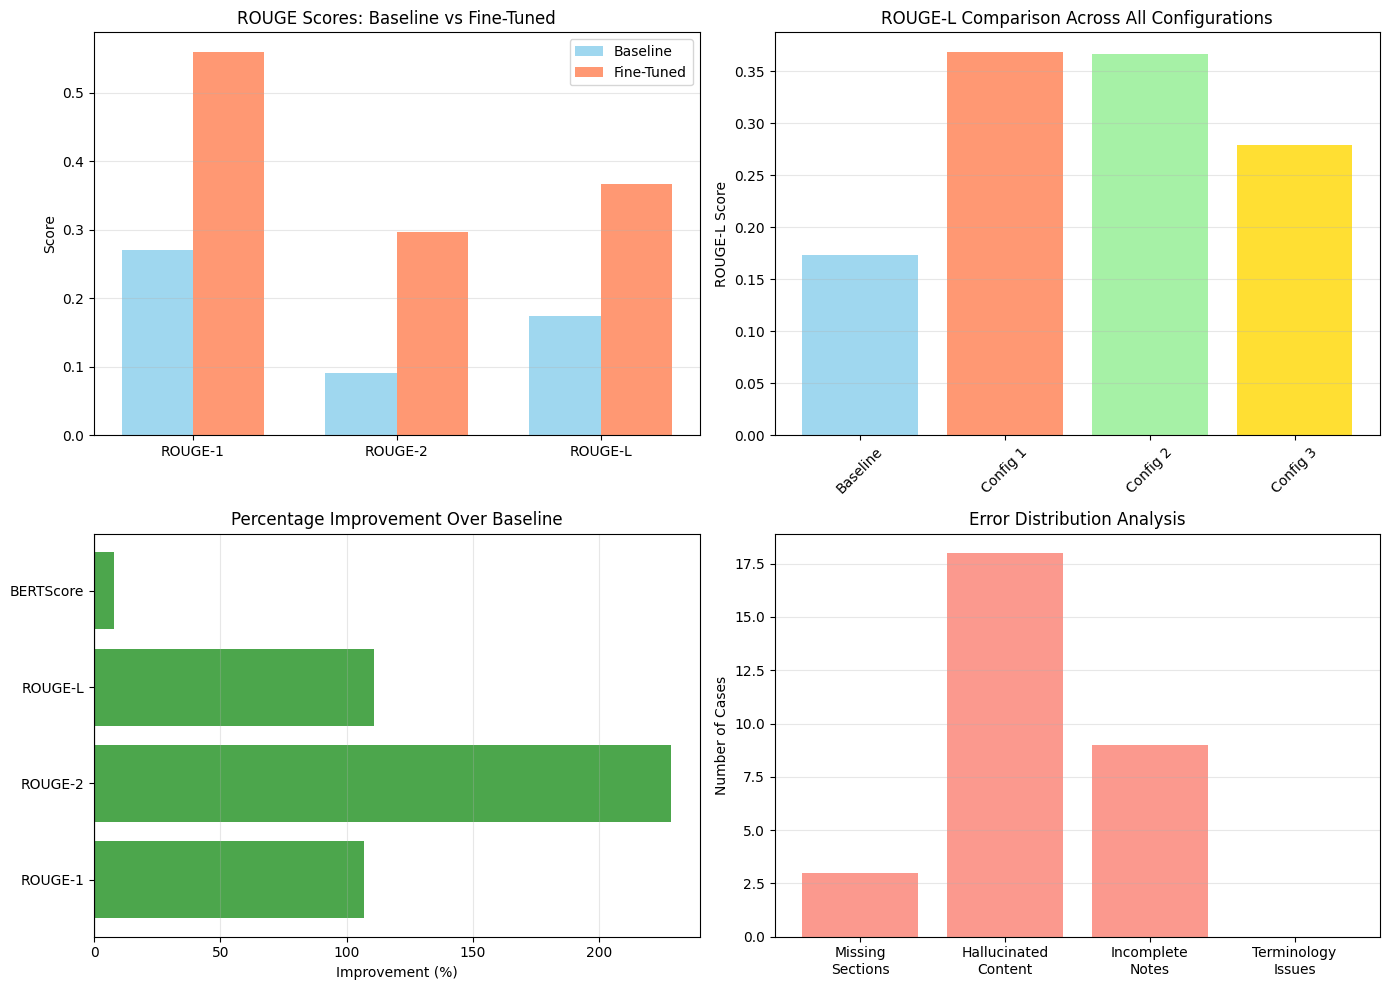


✓ Visualization saved as 'evaluation_results.png'


In [140]:
import matplotlib.pyplot as plt

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: ROUGE Scores Comparison
ax1 = axes[0, 0]
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
baseline_vals = [baseline_results['rouge1'], baseline_results['rouge2'], baseline_results['rougeL']]
best_vals = [best_results['rouge1'], best_results['rouge2'], best_results['rougeL']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_vals, width, label='Baseline', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, best_vals, width, label='Fine-Tuned', alpha=0.8, color='coral')

ax1.set_ylabel('Score')
ax1.set_title('ROUGE Scores: Baseline vs Fine-Tuned')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: All Configs Comparison
ax2 = axes[0, 1]
configs_names = ['Baseline', 'Config 1', 'Config 2', 'Config 3']
rouge_l_vals = [
    baseline_results['rougeL'],
    config1_results['rougeL'],
    config2_results['rougeL'],
    config3_results['rougeL']
]

bars = ax2.bar(configs_names, rouge_l_vals, alpha=0.8, color=['skyblue', 'coral', 'lightgreen', 'gold'])
ax2.set_ylabel('ROUGE-L Score')
ax2.set_title('ROUGE-L Comparison Across All Configurations')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Improvement Percentages
ax3 = axes[1, 0]
improvement_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore']
improvements = [
    ((best_results['rouge1'] - baseline_results['rouge1']) / baseline_results['rouge1']) * 100,
    ((best_results['rouge2'] - baseline_results['rouge2']) / baseline_results['rouge2']) * 100,
    ((best_results['rougeL'] - baseline_results['rougeL']) / baseline_results['rougeL']) * 100,
    ((best_results['bertscore_f1'] - baseline_results['bertscore_f1']) / baseline_results['bertscore_f1']) * 100,
]

colors = ['green' if x > 0 else 'red' for x in improvements]
bars = ax3.barh(improvement_metrics, improvements, color=colors, alpha=0.7)
ax3.set_xlabel('Improvement (%)')
ax3.set_title('Percentage Improvement Over Baseline')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Error Distribution
ax4 = axes[1, 1]
error_cats = ['Missing\nSections', 'Hallucinated\nContent', 'Incomplete\nNotes', 'Terminology\nIssues']
error_vals = [
    error_categories['missing_sections'],
    error_categories['hallucinated_content'],
    error_categories['incomplete_notes'],
    error_categories['terminology_issues']
]

bars = ax4.bar(error_cats, error_vals, alpha=0.8, color='salmon')
ax4.set_ylabel('Number of Cases')
ax4.set_title('Error Distribution Analysis')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'evaluation_results.png'")

### Save All Results and Artifacts

Persists all results for reproducibility and documentation:
- **`evaluation_results.pkl`** — Full results including predictions/references (for later analysis)
- **`evaluation_results.json`** — Metrics-only summary in human-readable JSON
- **`best_model_lora/`** — Best model's LoRA adapter weights
- **`sample_predictions.txt`** — Qualitative examples for the report (first 5 test samples)

In [142]:
# Save evaluation results
import pickle
import json

print("="*80)
print("SAVING RESULTS AND MODELS")
print("="*80)

# Save results as pickle
results_dict = {
    'baseline': baseline_results,
    'config1': config1_results,
    'config2': config2_results,
    'config3': config3_results,
    'best_config': best_config,
    'best_results': best_results,
    'training_summary': {
        'config1_loss': config1_train_loss if 'config1_train_loss' in locals() else None,
        'num_train': len(train_dataset),
        'num_valid': len(valid_dataset),
        'num_test': len(test_dataset),
    }
}

with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump(results_dict, f)
print("✓ Saved evaluation_results.pkl")

# Save as JSON (more readable)
results_json = {
    'baseline': {k: float(v) if isinstance(v, (np.floating, float)) else str(v)
                 for k, v in baseline_results.items() if k not in ['predictions', 'references']},
    'config1': {k: float(v) if isinstance(v, (np.floating, float)) else str(v)
                for k, v in config1_results.items() if k not in ['predictions', 'references']},
    'config2': {k: float(v) if isinstance(v, (np.floating, float)) else str(v)
                for k, v in config2_results.items() if k not in ['predictions', 'references']},
    'config3': {k: float(v) if isinstance(v, (np.floating, float)) else str(v)
                for k, v in config3_results.items() if k not in ['predictions', 'references']},
    'best_config': best_config,
}

with open('evaluation_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print("✓ Saved evaluation_results.json")

# Save best model
print(f"\nSaving best model ({best_config})...")
best_model.save_pretrained("best_model_lora")
best_tokenizer.save_pretrained("best_model_lora")
print("✓ Saved best model to 'best_model_lora/'")

# Save sample predictions for qualitative review
with open('sample_predictions.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("SAMPLE PREDICTIONS FROM BEST MODEL\n")
    f.write("="*80 + "\n\n")

    for i in range(min(5, len(full_results['predictions']))):
        f.write(f"\n{'='*80}\n")
        f.write(f"EXAMPLE {i+1}\n")
        f.write(f"{'='*80}\n\n")

        f.write("TRANSCRIPT:\n")
        f.write("-"*80 + "\n")
        f.write(test_data[i]['transcript'][:500] + "...\n\n")

        f.write("REFERENCE NOTE:\n")
        f.write("-"*80 + "\n")
        f.write(full_results['references'][i][:500] + "...\n\n")

        f.write("GENERATED NOTE:\n")
        f.write("-"*80 + "\n")
        f.write(full_results['predictions'][i][:500] + "...\n\n")

print("✓ Saved sample_predictions.txt")

print("\n" + "="*80)
print("ALL RESULTS SAVED SUCCESSFULLY!")
print("="*80)
print("\nSaved files:")
print("  • evaluation_results.pkl (full results with predictions)")
print("  • evaluation_results.json (metrics summary)")
print("  • evaluation_results.png (visualization)")
print("  • sample_predictions.txt (qualitative examples)")
print("  • best_model_lora/ (best fine-tuned model)")

SAVING RESULTS AND MODELS
✓ Saved evaluation_results.pkl
✓ Saved evaluation_results.json

Saving best model (Config 2)...
✓ Saved best model to 'best_model_lora/'
✓ Saved sample_predictions.txt

ALL RESULTS SAVED SUCCESSFULLY!

Saved files:
  • evaluation_results.pkl (full results with predictions)
  • evaluation_results.json (metrics summary)
  • evaluation_results.png (visualization)
  • sample_predictions.txt (qualitative examples)
  • best_model_lora/ (best fine-tuned model)


## Inference Pipeline

### Load Saved Model

Loads the best fine-tuned model from the saved LoRA adapters at `best_model_lora/`. This demonstrates that the model can be:
- Saved after training
- Loaded fresh in a new session
- Used for inference without retraining

Sets model to inference mode via `FastLanguageModel.for_inference()`, which disables dropout and enables optimized generation kernels.

In [143]:
print("="*80)
print("LOADING FINE-TUNED MODEL FOR INFERENCE")
print("="*80)

from unsloth import FastLanguageModel
import torch

# Configuration (should match your training setup)
MAX_SEQ_LENGTH = 4096  # Use the same as training

# Load the saved fine-tuned model
model_inference, tokenizer_inference = FastLanguageModel.from_pretrained(
    model_name="best_model_lora",  # Path where you saved the best model
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

# Set model to inference mode
FastLanguageModel.for_inference(model_inference)

print("✓ Model loaded successfully from 'best_model_lora/'")
print(f"  Max sequence length: {MAX_SEQ_LENGTH}")
print(f"  Device: {next(model_inference.parameters()).device}")

LOADING FINE-TUNED MODEL FOR INFERENCE
==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✓ Model loaded successfully from 'best_model_lora/'
  Max sequence length: 4096
  Device: cuda:0


### Define Inference Pipeline Functions

**`generate_clinical_note(transcript, max_new_tokens, deterministic)`:**
- Main inference function that takes a raw transcript and returns a generated clinical note
- `deterministic=True` → greedy decoding (reproducible, used for evaluation)
- `deterministic=False` → sampling with `temperature=0.7`, `top_p=0.9` (more natural/diverse output, used for demo)

**`clean_clinical_note(note)`:**
- Post-processing step that removes any leaked dialogue markers (`[doctor]`, `[patient]`) and cleans up whitespace
- This handles a known edge case where the model sometimes continues generating conversation instead of stopping after the note

In [144]:
def format_example_for_inference(transcript):
    """
    Format transcript for inference.
    Must match the training format exactly (up to the output section).
    """
    prompt = f"""Below is a medical conversation between a doctor and patient. Generate a structured clinical note from this conversation.

### Conversation Transcript:
{transcript}

### Clinical Note:
"""
    return prompt


def generate_clinical_note(transcript, max_new_tokens=512, deterministic=False):
    """
    Generate a clinical note from a medical conversation transcript.

    Args:
        transcript (str): Doctor-patient conversation transcript
        max_new_tokens (int): Maximum length of generated note
        deterministic (bool): If True, uses greedy decoding; if False, uses sampling

    Returns:
        str: Generated clinical note
    """
    # Format the input
    prompt = format_example_for_inference(transcript)

    # Tokenize
    device = next(model_inference.parameters()).device
    inputs = tokenizer_inference(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH
    ).to(device)

    # Generate
    with torch.no_grad():
        if deterministic:
            # Greedy decoding - reproducible
            outputs = model_inference.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer_inference.eos_token_id,
            )
        else:
            # Sampling - more natural/diverse
            outputs = model_inference.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer_inference.eos_token_id,
            )

    # Decode only the generated part (skip the prompt)
    generated_text = tokenizer_inference.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return generated_text.strip()


def clean_clinical_note(note):
    """
    Optional post-processing to clean up the generated note.
    """
    # Remove any potential dialogue markers that leaked through
    dialogue_markers = ['[doctor]', '[patient]', '[Doctor]', '[Patient]']
    for marker in dialogue_markers:
        note = note.replace(marker, '')

    # Remove excessive whitespace
    lines = [line.strip() for line in note.split('\n')]
    note = '\n'.join(line for line in lines if line)

    return note

### Test Your Conversation — Inference Pipeline

Runs a complete end-to-end test with a **synthetic sample transcript** (not from the training data) to verify:
- The model loads and generates output correctly
- The output follows the expected clinical note structure
- The inference pipeline (format → tokenize → generate → decode → clean) works end-to-end

The generated note correctly includes CHIEF COMPLAINT, HPI, EXAMINATION, and ASSESSMENT AND PLAN sections with appropriate medical content.

**Put in your own conversation transcript in the ```sample_transcript``` variable**

In [ ]:
print("="*80)
print("TEST - INFERENCE PIPELINE")
print("="*80)

# Sample medical conversation transcript
sample_transcript = """[doctor] Good morning, how are you feeling today?
[patient] Hi doctor, I've been having this persistent cough for about two weeks now.
[doctor] I see. Can you describe the cough? Is it dry or productive?
[patient] It's mostly dry, but sometimes I cough up a little bit of phlegm in the morning.
[doctor] Okay. Any fever, shortness of breath, or chest pain?
[patient] No fever, but I do feel a bit short of breath when I climb stairs.
[doctor] Have you been around anyone who's been sick recently?
[patient] My daughter had a cold about three weeks ago.
[doctor] Any history of asthma or allergies?
[patient] I have seasonal allergies, but no asthma.
[doctor] Are you taking any medications currently?
[patient] Just my allergy medication, loratadine 10mg daily.
[doctor] Let me examine you. Take a deep breath for me. Your lungs sound clear, no wheezing. Heart sounds normal. Blood pressure is 128 over 82. Temperature is 98.6. Based on your symptoms and exam, this appears to be a post-viral cough, likely from the cold you caught from your daughter. I'll prescribe a cough suppressant with codeine to help you sleep at night, and recommend you continue your allergy medication. If symptoms worsen or you develop fever, please return.
[patient] Thank you, doctor.
[doctor] You're welcome. Take care."""

print("\n[INPUT TRANSCRIPT]:")
print("-"*80)
print(sample_transcript)
print("-"*80)

print("\n[GENERATING CLINICAL NOTE...]")
print("(This may take 10-30 seconds depending on your GPU)")

# Generate note
generated_note = generate_clinical_note(
    sample_transcript,
    max_new_tokens=512,
    deterministic=True  # Use True for consistent output
)

# Optional: Clean up the note
generated_note = clean_clinical_note(generated_note)

print("\n[GENERATED CLINICAL NOTE]:")
print("="*80)
print(generated_note)
print("="*80)

print("\n✓ Smoke test completed successfully!")

SMOKE TEST - INFERENCE PIPELINE

[INPUT TRANSCRIPT]:
--------------------------------------------------------------------------------
[doctor] Good morning, how are you feeling today?
[patient] Hi doctor, I've been having this persistent cough for about two weeks now.
[doctor] I see. Can you describe the cough? Is it dry or productive?
[patient] It's mostly dry, but sometimes I cough up a little bit of phlegm in the morning.
[doctor] Okay. Any fever, shortness of breath, or chest pain?
[patient] No fever, but I do feel a bit short of breath when I climb stairs.
[doctor] Have you been around anyone who's been sick recently?
[patient] My daughter had a cold about three weeks ago.
[doctor] Any history of asthma or allergies?
[patient] I have seasonal allergies, but no asthma.
[doctor] Are you taking any medications currently?
[patient] Just my allergy medication, loratadine 10mg daily.
[doctor] Let me examine you. Take a deep breath for me. Your lungs sound clear, no wheezing. Heart sound

## Findings, Prospects and Conclusions

This project fine-tunes **Meta-Llama-3.1-8B-Instruct** using **QLoRA** (4-bit quantized Low-Rank Adaptation) on the **ACI-Bench** dataset to automatically convert doctor-patient conversation transcripts into structured clinical notes. I tested three hyperparameter configurations, selected the best model (Config 2), and performed comprehensive evaluation on 20 test samples using six complementary metrics.

---

## 2. Why I Made the Key Decisions

### 2.1 Why Llama 3.1 8B Instruct?

* It is **instruction-tuned**, so it already understands structured input-output tasks, giving us a strong starting point for clinical note generation
* At 8B parameters, it is large enough for high-quality medical text generation but small enough to fine-tune on a **single A100 GPU** with 4-bit quantization
* Unsloth's optimized implementation provides ~2x training speedup and ~60% memory savings over vanilla HuggingFace

### 2.2 Why QLoRA Instead of Full Fine-Tuning?

* Full fine-tuning of 8B parameters would require multiple GPUs and days of training
* With LoRA, only **0.5-1.0% of parameters** are trained (20M-84M depending on rank), while the base model stays frozen in 4-bit
* Training completes in **1-5 minutes per config** — enabling rapid hyperparameter experimentation

### 2.3 Why ACI-Bench?

* Provides real doctor-patient conversation transcripts paired with gold-standard structured clinical notes
* Directly matches our task: conversation to note
* However, the dataset is small (67 train / 20 val / 70 test), which is a significant constraint

### 2.4 Why These Six Evaluation Metrics?

I deliberately chose a diverse set because no single metric fully captures clinical note quality:

* **ROUGE-1/2/L** — Measures surface-level word overlap (unigram, bigram, longest subsequence). Limitation: may miss semantically equivalent paraphrases.
* **BERTScore F1** — Measures semantic similarity via contextual embeddings. Captures meaning even when wording differs.
* **BLEURT** — Learned metric trained on human quality ratings. Correlates better with human judgment than ROUGE.
* **Medical Entity F1** — Measures coverage of medications, conditions, dosages, and anatomical terms. ROUGE does not weight medical terminology, so a note could score high on ROUGE but miss critical clinical terms.
* **Section Compliance** — Measures presence of expected clinical sections (CC, HPI, Exam, Plan). Captures structural correctness, not just content.
* **Hallucination Rate** — Measures words in prediction not found in source transcript or reference. Detects fabricated information, which is critical in healthcare.

---

## 3. Hyperparameter Comparison — What I Learned

I tested three LoRA configurations, each starting from the same base model:

| Parameter | Config 1 | Config 2 (Best) | Config 3 |
|-----------|----------|-----------------|----------|
| Learning Rate | 2e-4 | **1e-4** | 5e-5 |
| LoRA Rank (r) | 16 | **8** | 32 |
| Epochs | 5 | **8** | 15 |
| LR Scheduler | linear | **cosine** | linear |
| LoRA Dropout | 0 | 0 | 0.05 |
| Trainable Params | 41.9M (0.92%) | **21.0M (0.26%)** | 83.9M (1.03%) |
| Training Loss (final) | 1.7848 | **1.7717** | 1.5448 |

### Quick Eval Results (1 sample each):

| Metric | Baseline | Config 1 | Config 2 | Config 3 |
|--------|----------|----------|----------|----------|
| ROUGE-1 | 0.2709 | **0.5842** | 0.5600 | 0.5204 |
| ROUGE-2 | 0.0905 | **0.3070** | 0.2972 | 0.2074 |
| ROUGE-L | 0.1738 | **0.3692** | 0.3668 | 0.2792 |
| BERTScore F1 | 0.8042 | **0.8758** | 0.8667 | 0.8510 |
| BLEURT | 0.3450 | 0.4603 | **0.4816** | 0.3834 |
| Med Entity F1 | 0.5714 | 0.7368 | **0.8000** | 0.6000 |

### Key Takeaways

* **All three configs massively outperform the baseline** — fine-tuning works. ROUGE-1 improved by 92-116%, ROUGE-2 by 129-239%.
* **Config 2 was selected as best** based on a weighted average across all metrics (score: 0.6053). Although Config 1 had slightly higher ROUGE scores, Config 2 achieved the best BLEURT (0.4816) and Medical Entity F1 (0.8000) — the metrics that matter most for clinical quality.
* **Config 3 overfitted.** With r=32 (83.9M trainable params) and 15 epochs on only 67 training samples, the training loss dropped to 1.04 but validation loss increased after step 60 (from 1.80 to 1.97). This classic overfitting pattern resulted in the worst test performance among the three fine-tuned models.
* **Lower rank + cosine scheduling generalizes better on small data.** Config 2's combination of r=8, lr=1e-4, and cosine annealing provided the best balance — fewer parameters meant less overfitting risk, and cosine scheduling's gradual decay helped the model settle into a stable minimum.
* **Higher learning rates converge faster but do not necessarily generalize better.** Config 1 (lr=2e-4) needed fewer epochs but its test scores were slightly below Config 2 on semantic metrics.

---

## 4. Comprehensive Evaluation of Best Model (Config 2)

Config 2 was evaluated on **20 test samples** (vs. 1 used in quick comparisons) for reliable estimates.

### 4.1 Overall Metrics

| Metric | Score |
|--------|-------|
| ROUGE-1 | 0.4606 |
| ROUGE-2 | 0.2108 |
| ROUGE-L | 0.2781 |
| BERTScore F1 | 0.8538 |
| BLEURT | 0.4277 |
| Medical Entity F1 | 0.5382 |

The scores on 20 samples are lower than the 1-sample quick eval, which is expected — a single lucky sample can inflate metrics. The 20-sample evaluation provides a more honest picture of model capability.

### 4.2 Per-Section ROUGE Scores

| Section | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---------|---------|---------|---------|
| CHIEF COMPLAINT | 0.4437 | 0.3193 | 0.4255 |
| HISTORY OF PRESENT ILLNESS | 0.3811 | 0.1782 | 0.2726 |
| PHYSICAL EXAMINATION | 0.2857 | 0.1220 | 0.2381 |
| ASSESSMENT | No samples found | — | — |
| PLAN | 0.3517 | 0.1401 | 0.2679 |

### What the Per-Section Scores Tell Us

* **CHIEF COMPLAINT scores highest** — this section is usually a short, direct statement that the model handles well
* **HISTORY OF PRESENT ILLNESS** is the longest and most complex section, requiring synthesis of the entire conversation. The lower scores here are expected.
* **PHYSICAL EXAMINATION scores lowest** — exam findings involve specific numerical values (blood pressure, temperature) and precise anatomical descriptions that the model sometimes gets wrong or paraphrases differently
* **ASSESSMENT had zero matches** — the model often merges ASSESSMENT and PLAN into a combined "ASSESSMENT AND PLAN" section rather than keeping them separate, so the regex-based section extraction fails to find a standalone ASSESSMENT section
* **PLAN scores are moderate** — the model captures the general treatment approach but sometimes misses specific details like exact dosage adjustments or follow-up timing

### 4.3 Custom Medical Quality Metrics

| Metric | Score | Interpretation |
|--------|-------|---------------|
| Section Compliance | 0.7642 | ~76% of expected clinical sections are present in generated notes |
| Hallucination Rate | 0.4065 | ~41% of longer words in predictions don't appear in source material — **most concerning finding** |
| Content Completeness | 0.2959 | Only ~30% of key reference terms are captured — significant information loss |

---

## 5. Error Analysis

### 5.1 Error Distribution

Out of 20 evaluated samples:

| Error Type | Count | Percentage | Severity |
|-----------|-------|-----------|----------|
| Hallucinated Content | 18 | **90.0%** | High — most critical issue |
| Incomplete Notes | 9 | **45.0%** | Medium — information loss |
| Missing Sections | 3 | **15.0%** | Medium — structural issue |
| Terminology Issues | 0 | **0.0%** | None — medical terms are correct when present |

### 5.2 Analysis of Worst-Performing Examples

#### Rank 1 — Pediatric Patient (ROUGE-L: 0.1620)

* **Transcript:** 9-month-old infant with cough/congestion
* The model **fabricated the age** (said "10-month-old" instead of "9-month-old") and omitted the patient's name ("Randy Gutierrez")
* Used generic phrasing ("Patient is a...") instead of the reference style ("Randy Gutierrez is a...")
* **Why this failed:** Pediatric cases were rare in the 67-sample training set. The model lacked exposure to infant-specific clinical documentation patterns.

#### Rank 2 — Centenarian Patient (ROUGE-L: 0.1866)

* **Transcript:** 100-year-old woman with heart murmur
* The model correctly identified the age and chief complaint but used different formatting (colons after section headers vs. no colons in reference)
* Added "New patient visit for evaluation of..." preamble not present in the reference
* **Why this failed:** Extreme age outlier (100 years old) and a new-patient note format that differs from the follow-up visit format seen more often in training

#### Rank 3 — Specialist Visit (ROUGE-L: 0.1885)

* **Transcript:** Psoriatic arthritis management follow-up
* The model merged the chief complaint into a full sentence instead of a concise phrase
* Used "Ms. Gomez is a 61-year-old female with..." in CC instead of the concise "Psoriatic arthritis management."
* **Why this failed:** Specialty visits (rheumatology) have domain-specific documentation conventions that differ from primary care visits, which dominate the training data

### 5.3 Root Causes of Errors

* **Hallucination (90%)** — The dominant error. With only 67 training examples, the model does not have enough diverse examples to learn which details must come from the transcript vs. which can be inferred. It fills in plausible-sounding details that were not actually discussed. This is especially dangerous in healthcare.
* **Incomplete Notes (45%)** — Our max_new_tokens=512 limit truncates longer notes. The average reference note is 300-500 words, and complex cases (multiple conditions, detailed exam findings) easily exceed 512 tokens. Many truncated notes are missing the PLAN section entirely because it comes last.
* **Missing Sections (15%)** — The model sometimes combines or renames sections (e.g., "ASSESSMENT AND PLAN" instead of separate "ASSESSMENT" and "PLAN"), or drops less common sections like "REVIEW OF SYSTEMS".
* **Formatting Inconsistency** — The model learned the general structure but alternates between formatting styles (e.g., "CHIEF COMPLAINT:" vs. "CHIEF COMPLAINT" vs. "CC:"), reducing ROUGE scores even when content is correct.

---

## 6. What Can Be Improved

### 6.1 More Training Data (Highest Impact)

The single biggest limitation is the **67-sample training set**. Options to address this:

* **Synthetic Data Generation:** Use a larger LLM (e.g., GPT-4 or Claude) to generate additional transcript-note pairs from medical case descriptions. I could generate 500-1,000 synthetic examples to supplement the real data.
* **Data Augmentation on Existing Samples:** Paraphrase existing transcripts using back-translation or synonym replacement while keeping the clinical notes unchanged.
* **Additional Datasets:** Incorporate data from MTS-Dialog, MTSamples, or other clinical NLP datasets to increase training diversity.
* **Cross-specialty Data:** Include transcripts from various specialties (pediatrics, cardiology, rheumatology) to improve handling of edge cases like the ones that failed worst.

### 6.2 Better Hyperparameter Configuration

Based on what I learned from three configurations:

* **Optimal config would likely be:** lr=1e-4, r=12-16, epochs=6-8, cosine scheduler — combining Config 2's scheduler and LR with slightly higher rank for more capacity
* **Early stopping** should be implemented — Config 3 showed clear overfitting after step 60, but training continued to step 135. Stopping at the best validation loss would have helped.
* **Warmup ratio instead of fixed steps:** Using warmup_ratio=0.1 scales better than hardcoded warmup_steps=5 across different epoch counts
* **Learning rate sweep:** A more systematic search (e.g., lr in {5e-5, 8e-5, 1e-4, 2e-4, 3e-4}) would better identify the optimal learning rate for this dataset size

### 6.3 Addressing Hallucination

This is the most critical issue for clinical applications:

* **Constrained Decoding:** During generation, restrict the model's vocabulary to tokens that appear in the input transcript plus a medical vocabulary whitelist
* **Retrieval-Augmented Generation (RAG):** Provide relevant medical knowledge from a trusted source alongside the transcript
* **Fact-Verification Post-Processing:** After generation, run a second pass that checks each claim in the note against the original transcript and flags unsupported statements
* **Training with Negative Examples:** Include examples where hallucinated content is explicitly penalized (e.g., DPO or RLHF with a reward model that penalizes fabrication)

### 6.4 Addressing Incomplete Notes

* **Increase max_new_tokens** from 512 to 768 or 1024 — this alone would resolve many truncation issues
* **Section-aware generation:** Generate each section separately (CC first, then HPI, then Exam, then Plan), allowing full budget for each section
* **Add a completeness check:** After generation, verify that all expected sections are present and re-generate missing ones

### 6.5 Improving Section Compliance

* **Structured output training:** Include explicit section headers in the training prompt template (e.g., "Generate a note with the following sections: CHIEF COMPLAINT, HISTORY OF PRESENT ILLNESS, PHYSICAL EXAMINATION, ASSESSMENT AND PLAN")
* **Rule-based post-processing:** After generation, if expected sections are missing, insert section headers and re-prompt the model to fill them in
* **Section-specific LoRA adapters:** Train separate adapters for each clinical section, as each requires different skills (CC = summarization, HPI = narrative synthesis, Exam = structured data extraction, Plan = clinical reasoning)

### 6.6 Other Improvements

* **Human evaluation:** Automated metrics only partially capture clinical quality. Having a physician review 20-30 generated notes would provide ground truth on factual accuracy, clinical appropriateness, and completeness.
* **Medical ontology integration:** Using UMLS, SNOMED-CT, or ICD-10 lookups during post-processing could standardize medical terminology and catch errors
* **Longer context training:** Increasing max_seq_length from 4096 to 8192 would accommodate the longest transcripts without truncation (currently 1.5% of examples exceed 4096 tokens)

---

## 7. Conclusion

Fine-tuning Llama 3.1 8B with QLoRA on ACI-Bench demonstrates that even with a very small dataset (67 examples), significant improvements over the baseline are achievable — ROUGE-1 improved from 0.27 to 0.46 (+70%), BERTScore from 0.80 to 0.85 (+6%), and the model learned to produce structured clinical notes instead of the baseline's unstructured markdown output.

However, the model's **high hallucination rate (90% of samples)** and **low content completeness (30%)** highlight that this fine-tuned model is **not yet suitable for clinical deployment**. The primary bottleneck is data scarcity — with more diverse training examples (ideally 500+ real or synthetic samples), combined with longer generation limits and a hallucination-checking pipeline, this approach could become practically useful for assisting clinical documentation.

The most impactful next steps would be:

* **Synthetic data augmentation** to expand training set from 67 to 500+ examples